## Advanced calibration methods and VIX derivatives
### Master M2MO, Université Paris Cité
### Master 2 Probabilités et Finance, Sorbonne Université and École polytechnique
# Computing assignment

### Due Date: 11:59 PM Sunday, April 12, 2026

You should turn in the notebook on the Moodle course website. You are expected to work in groups of 3 preferably, or possibly groups of 2.

Please comment your code properly.

Before you turn in the notebook, press the "Run all cells" button in the toolbar, and make sure all the calculation results and graphs are produced correctly in a reasonable time frame, and then save the notebook under the name ComputingAssignmentACMVix-FirstName1LastName1-FirstName2LastName2-FirstName3LastName3.ipynb

<h3 style="color:deepskyblue">1. The Particle Method for Smile Calibration</h3>

Consider the stochastic local volatility (SLV) model

$$
\begin{array}{l}
dS_t = a_t l(t, S_t) S_t dW^{(1)}_t\\
a_t=\sigma_0 e^{Y_t}\quad\text{where}\quad d Y_t = -\kappa Y_tdt+\gamma dW^{(2)}_t\\
d \langle W^{(1)}, W^{(2)} \rangle_t = \rho dt.
\end{array}
$$

The numerical values for the model parameters are
- $T = 1$.
- $S_0 = 100$.
- $\sigma_0 = 15\%$.
- $Y_0 = 0$.
- $\rho = -50\%$.
- $\gamma = 50\%$.
- $\kappa = 1$.

The goal is to find a leverage function $l(t, S)$ so that this model matches the market prices of vanilla options. For the sake of simplicity, we assume that the market implied volatility surface is flat $\sigma_{\textrm{Market}} \equiv 15\%$. In that case, we also have $\sigma_{\textrm{Dup}}(t,S) \equiv 15\%$.

#### Monte-Carlo Scheme
Below we describe a Monte Carlo simulation scheme for the SLV model.

First we discretize the interval $(0,T)$ into subintervals $(t_{i-1}, t_i)$, $1\leq i\leq n$, and set $\Delta t_i=t_i-t_{i-1}$.

The Ornstein-Uhlenbeck process $Y$ is explicitly solvable:
$$
\begin{equation}
Y_{t_i}=e^{-\kappa\Delta t_i}Y_{t_{i-1}}+\int_{t_{i-1}}^{t_i}\gamma e^{-\kappa\left(t_i-s\right)}dW_s^{(2)}.
\end{equation}
$$

Therefore for given $Y_{t_{i-1}}$, $Y_{t_i}$ is a Gaussian variable with
$$
\begin{equation}\tag{1}
\mathbb{E}\left[\left.Y_{t_i}\right\vert Y_{t_{i-1}}\right]=e^{-\kappa\Delta t_i}Y_{t_{i-1}},\quad
\text{Var}\left[\left.Y_{t_i}\right\vert Y_{t_{i-1}}\right]=\frac{\gamma^2}{2\kappa}\left(1-e^{-2\kappa\Delta t_i}\right)
\end{equation}
$$

so that paths of $Y$ can be simulated exactly.

To simulate the spot process $S$, we use the Euler scheme:
$$\log S_{t_i}-\log S_{t_{i-1}}=-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i+\sigma_0 e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\int_{t_{i-1}}^{t_i}dW^{(1)}_t$$

Thus for given $S_{t_{i-1}}$ and $Y_{t_{i-1}}$, $\log S_{t_i}$ and $Y_{t_i}$ are jointly Gaussian variables with
$$
\begin{equation}\tag{2}
\mathbb{E}\left[\left.\log S_{t_i}\right\vert S_{t_{i-1}},Y_{t_{i-1}}\right]=\log S_{t_{i-1}}-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}\Delta t_i,\quad\text{Var}\left[\left.\log S_{t_i}\right\vert S_{i_{i-1}}, Y_{t_{i-1}}\right]=\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i
\end{equation}
$$
$$
\begin{equation}\tag{3}
\text{Cov}\left[\left.Y_{t_i},\log S_{t_i}\right\vert S_{t_{i-1}}, Y_{t_{i-1}}\right]=\sigma_0 e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\frac{\gamma\rho}{\kappa}\left(1-e^{-\kappa\Delta t_i}\right)
\quad\text{or}\quad
\text{Corr}\left[\left.Y_{t_i},\log S_{t_i}\right\vert S_{t_{i-1}}, Y_{t_{i-1}}\right]=\rho\sqrt{\frac{2(1-e^{-\kappa\Delta t_i})}{\kappa\Delta t_i(1+e^{-\kappa\Delta t_i})}}
\end{equation}
$$
Over the time interval $[t_{i-1}, t_i]$, we can advance $\log S$ and $Y$ by generating Gaussian variables $\log S_{t_i}$ and $Y_{t_i}$ using equations (1)-(3). That is,

\begin{align}
\log S_{t_i} &= \log S_{t_{i-1}}-\frac{1}{2}\sigma_0^2e^{2Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})^2\Delta t_i+\sigma_0e^{Y_{t_{i-1}}}l(t_{i-1},S_{t_{i-1}})\sqrt{\Delta t_i}\left(\sqrt{1-\bar{\rho}^2}Z_1+\bar{\rho}Z_2\right),\quad\text{where }\bar{\rho}=\rho\sqrt{\frac{2(1-e^{-\kappa\Delta t_i})}{\kappa\Delta t_i(1+e^{-\kappa\Delta t_i})}}\\
Y_{t_i} &= e^{-\kappa\Delta t_i}Y_{t_{i-1}}+\gamma\sqrt{\frac{1-e^{-2\kappa\Delta t_i}}{2\kappa}}Z_2
\end{align}
where $Z_1$ and $Z_2$ are independent standard normal variables.

<b>(a).</b> Implementation of the Particle Method.
- Implement the particle method studied in class to find the leverage function $l$. We suggest that for the kernel regression you use the quartic kernel

$$\delta(x)=(x+1)^2(1-x)^2\quad\text{for }-1\leq x\leq 1\quad\text{and}\quad0\quad\text{ elsewhere}$$

together with the bandwidth

$$h = \kappa \sigma_{\mathrm{Market}} S_0 \sqrt{\max(t_k,0.15)}N^{-0.2}$$

at discretization date $t_k$. We recall that the rescaled kernel is

$$ \delta_h(x) = \frac{1}{h}\delta\left(\frac{x}{h}\right). $$

Make sure to fine-tune the dimensionless bandwidth parameter $\kappa$. Its order of magnitude is 1.0. Use $\Delta t = 1/100$, $N=10,000$ paths. Note: In class, we described an acceleration technique that involves sorting the "particles" $(S_{t_k},a_{t_k})$ according to the spot value $S_{t_k}$. Since the kernel we have chosen has compact support and is fairly inexpensive to evaluate, you may ignore this acceleration technique here. This means that each estimation of a conditional expectation $\mathbb{E}\left[\left.a_{t_k}^2\right\vert S_{t_k}=x\right]$ (for $x$ in a grid $G_{t_k}$ of spot values) involves the ratio of two sums of $N$ terms each. For the minimum and maximum values of $G_{t_k}$, take the 0.1% and 99.9% quantiles of the risk-neutral distribution of $S$ at $t_k$, i.e., since the smile is flat at $\sigma_{\textrm{Market}}$, of the distribution of $S_0\exp(\sigma_{\textrm{Market}}\sqrt{t_k}G - \frac12 \sigma_{\textrm{Market}}^2 t_k)$, with $G$ a standard Gaussian random variable. We suggest that the grid $G_{t_k}$ contain 30 equally spaced spot values.

- Check that the resulting model is indeed calibrated to the market implied volatilities $\sigma_{\textrm{Market}} \equiv 15\%$. To this end, compute estimates of the call prices (maturity $T=1$) in the calibrated model for strikes $70, 80, 90, 100, 110, 120, 130, 140$, and invert the Black-Scholes formula to get the corresponding estimation of the implied volatilities $\hat\sigma(T,K)$. To estimate the call prices in the calibrated model, simulate a new set of independent paths with the calibrated leverage function $l$ and $N_2 = 100,000$ paths. For the inversion of the Black-Scholes formula, you can use the function <code>blackscholes_impv</code> provided below.

In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import minimize_scalar
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
def blackscholes_price(K, T, S, vol, r=0, q=0, callput='call'):
    """Compute the call/put option price in Black-Scholes model

    Parameters
    ----------
    K: scalar or array_like
        The strike of the option.
    T: scalar or array_like
        The maturity of the option.
    S: scalar or array_like
        The spot price of the underlying security.
    vol: scalar or array_like
        The implied Black-Scholes volatility.
    callput: str
        Must be either 'call' or 'put'

    Returns
    -------
    price: scalar or array_like
        The price of the option.

    Examples
    --------
    >>> blackscholes_price(95, 0.25, 100, 0.2, r=0.05, callput='put')
    1.5342604771222823
    """
    F = S*np.exp((r-q)*T)
    w = vol**2*T
    d1 = (np.log(F/K)+0.5*w)/np.sqrt(w)
    d2 = d1 - np.sqrt(w)
    callput = callput.lower()
    if callput == 'call':
        opttype = 1
    elif callput == 'put':
        opttype = -1
    else:
        raise ValueError('The value of callput must be either "call" or "put".')
    price = (opttype*F*norm.cdf(opttype*d1)-opttype*K*norm.cdf(opttype*(d2)))*np.exp(-r*T)
    return price

In [ ]:
# all inputs must be scalar
def blackscholes_impv_scalar(K, T, S, value, r=0, q=0, callput='call', tol=1e-6, maxiter=500):
    """Compute implied vol in Black-Scholes model

    Parameters
    ----------
    K: scalar
        The strike of the option.
    T: scalar
        The maturity of the option.
    S: scalar
        The spot price of the underlying security.
    value: scalar
        The value of the option
    callput: str
        Must be either 'call' or 'put'

    Returns
    -------
    vol: scalar
        The implied vol of the option.
    """
    if (K <= 0) or (T <= 0):
        return np.nan
    F = S*np.exp((r-q)*T)
    K = K/F
    value = value*np.exp(r*T)/F
    callput = callput.lower()
    if callput not in ['call', 'put']:
        raise ValueError('The value of "callput" must be either "call" or "put"')
    opttype = 1 if callput == 'call' else -1
    value -= max(opttype * (1 - K), 0)
    if value < 0:
        return np.nan
    if (value == 0):
        return 0
    j = 1
    p = np.log(K)
    if K >= 1:
        x0 = np.sqrt(2 * p)
        x1 = x0 - (0.5 - K * norm.cdf(-x0) - value) * np.sqrt(2*np.pi)
        while (abs(x0 - x1) > tol*np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p/x1+0.5*x1
            x1 = x1 - (norm.cdf(d1) - K*norm.cdf(d1-x1)-value)*np.sqrt(2*np.pi)*np.exp(0.5*d1**2)
            j += 1
        return x1 / np.sqrt(T)
    else:
        x0 = np.sqrt(-2 * p)
        x1 = x0 - (0.5*K-norm.cdf(-x0)-value)*np.sqrt(2*np.pi)/K
        while (abs(x0-x1) > tol*np.sqrt(T)) and (j < maxiter):
            x0 = x1
            d1 = -p/x1+0.5*x1
            x1 = x1-(K*norm.cdf(x1-d1)-norm.cdf(-d1)-value)*np.sqrt(2*np.pi)*np.exp(0.5*d1**2)
            j += 1
        return x1/np.sqrt(T)

# vectorized version
blackscholes_impv = np.vectorize(blackscholes_impv_scalar, excluded={'callput', 'tol', 'maxiter'})

# Example
blackscholes_impv(K=95, T=0.25, S=100, value=7, callput='call')

array(0.20654803)

In [ ]:
def quartic_kernel(x):
    x = np.clip(x, -1, 1)
    return (x+1)**2*(1-x)**2

#### Question 1

## Particle Algorithm for SLV Model Calibration

Let $\{t_k\}$ denote a time discretization of $[0, T]$ with $t_k = k\Delta t$ and $\Delta t = 1/100$. The particle algorithm, used here, proceeds as follows.

**(1)** Initialize $k := 1$ and set $l(t, S) = \sigma_\text{Mkt} / a_0$ for all $t \in [t_0 = 0, t_1]$, where $a_0 = \sigma_0 e^{Y_0}$ is the initial instantaneous volatility.

**(2)** Simulate the $N = 10{,}000$ particles $\{S_{t_k}^{i,N},\, a_{t_k}^{i,N}\}_{i=1,\ldots,N}$ from $t_{k-1}$ to $t_k$ using a log-Euler scheme for $S$ and the exact OU scheme for $Y$, with the effective volatility $\sigma_{\text{eff}}^{(i)} = a_{t_{k-1}}^{(i)} \cdot l(t_{k-1}, S_{t_{k-1}}^{(i)})$ and the discretized correlation $\bar\rho = \rho\sqrt{2(1-e^{-\kappa\Delta t})/(\kappa\Delta t(1+e^{-\kappa\Delta t}))}$, as implemented in `particle_method`.

**(3)** For each $x$ in a grid $G_{t_k}$ of 30 equally spaced spot values — computed by `spot_grid` — spanning the $0.1\%$–$99.9\%$ quantiles of the risk-neutral distribution of $S_{t_k}$, compute the leverage function via the Nadaraya-Watson estimator

$$l(t_k, x)^2 = \frac{\sigma_{\text{Mkt}}^2}{\mathbb{E}\left[a_{t_k}^2 \mid S_{t_k} = x\right]}$$

with $\mathbb{E}\left[a_{t_k}^2 \mid S_{t_k} = x\right]$ estimated via Nadaraya-Watson kernel regression implemented in `kernel_regression`, i.e.

$$\hat{m}(x) = \frac{\displaystyle\sum_{i=1}^{N} \delta_h\!\left(S_{t_k}^{i,N} - x\right)\, \left(a_{t_k}^{i,N}\right)^2}{\displaystyle\sum_{i=1}^{N} \delta_h\!\left(S_{t_k}^{i,N} - x\right)}$$

where the quartic kernel $\delta(u) = (u+1)^2(1-u)^2\,\mathbf{1}_{|u|\leq 1}$ — implemented in `quartic_kernel` — and the bandwidth $h = \kappa_{\text{bw}}\,\sigma_{\text{Mkt}}\,S_0\sqrt{\max(t_k, 0.15)}\,N^{-1/5}$ — computed by `bandwidth`— are used. The dimensionless constant $\kappa_{\text{bw}}$ is selected once at $k=1$ by leave-one-out cross-validation via *cv\_bandwidth*, minimizing $N^{-1}\sum_{i=1}^N (a_{t_1}^{(i)\,2} - \hat{m}_{-i}(S_{t_1}^{(i)}))^2$ over $\kappa_{\text{bw}} \in [0.3, 3.0]$, and reused at all subsequent steps.

Moreover, in order to obtain a continuous leverage function defined on the full spot domain, we interpolate $l(t_k, \cdot)$ using a cubic spline on $G_{t_k}$, and extrapolate flat outside $[\min G_{t_k}, \max G_{t_k}]$. Set $l(t, \cdot) \equiv l(t_k, \cdot)$ for all $t \in [t_k, t_{k+1}]$.

**(4)** Set $k := k+1$. Iterate steps 2 and 3 up to the maturity date $T$.

The calibration is validated by simulating $N_2 = 100{,}000$ independent paths via `simulate_calibrated` with the calibrated splines and verifying that the implied volatilities — inverted from Monte Carlo call prices at maturity $T = 1$ using `blackscholes_impv` — are uniformly equal to $\sigma_{\text{Mkt}} = 15\%$ across strikes $K \in \{70, 80, 90, 100, 110, 120, 130, 140\}$.

In [ ]:
def spot_grid(tk, S0, sigma_mkt, n_points=30):
    """Spot price grid G_{t_k} spanning the 0.1%–99.9% log-normal quantile range.

    Parameters
    ----------
    tk : float
        Current time (years). Returns np.array([S0]) if <= 0.
    S0 : float
        Initial spot price.
    sigma_mkt : float
        Flat implied volatility.
    n_points : int, optional
        Number of grid points. Default is 30.

    Returns
    -------
    grid : ndarray of shape (n_points,)
    """
    if tk <= 0:
        return np.array([S0])
    S_min = S0 * np.exp(sigma_mkt * np.sqrt(tk) * norm.ppf(0.001)
                        - 0.5 * sigma_mkt**2 * tk)
    S_max = S0 * np.exp(sigma_mkt * np.sqrt(tk) * norm.ppf(0.999)
                        - 0.5 * sigma_mkt**2 * tk)
    return np.linspace(S_min, S_max, n_points)

In [ ]:

def bandwidth(kappa_bw, tk, sigma_mkt, S0, N):
    """Kernel bandwidth h = kappa_bw * sigma_mkt * S0 * sqrt(max(tk, 0.15)) * N^(-1/5).

    Parameters
    ----------
    kappa_bw : float
        Tuning constant, optimised via `cv_bandwidth`.
    tk : float
        Current time (years). Floored at 0.15.
    sigma_mkt : float
        Flat implied volatility.
    S0 : float
        Initial spot price.
    N : int
        Number of particles.

    Returns
    -------
    h : float
        Bandwidth in spot-price units.
    """
    return kappa_bw * sigma_mkt * S0 * np.sqrt(max(tk, 0.15)) * N**(-0.2)

In [ ]:
def cv_bandwidth(S_particles, a2_particles, tk, sigma_mkt, S0, N, bounds=(0.3, 3.0)):
    """Optimal kappa_bw via leave-one-out cross-validation on the quartic kernel regression.

    Called once at k=1; the result is reused at all subsequent steps.

    Parameters
    ----------
    S_particles : ndarray of shape (N,)
    a2_particles : ndarray of shape (N,)
        Squared local vol a^2 = (sigma0 * exp(Y))^2 per particle.
    tk, sigma_mkt, S0, N
        Forwarded to `bandwidth`.
    bounds : tuple of (float, float), optional
        Search interval for kappa_bw. Default is (0.3, 3.0).

    Returns
    -------
    kappa_opt : float
    """
    def cv_loss(kappa_bw):
        h = bandwidth(kappa_bw, tk, sigma_mkt, S0, N)
        u   = (S_particles[None, :] - S_particles[:, None]) / h
        W   = quartic_kernel(u)
        np.fill_diagonal(W, 0.0)
        num_loo = W @ a2_particles
        den_loo = W.sum(axis=1)
        valid   = den_loo > 1e-10
        m_hat   = np.where(valid, num_loo / den_loo, a2_particles.mean())
        return np.mean((a2_particles - m_hat)**2)

    result = minimize_scalar(cv_loss, bounds=bounds, method='bounded')
    return result.x

In [ ]:
def kernel_regression(S_particles, a2_particles, grid, h):
    """Nadaraya-Watson estimate of E[a^2 | S = s] for each s in grid, using quartic kernel.

    Falls back to the global mean of a2_particles where the denominator
    is below 1e-12. Output is clipped to [1e-8, inf).

    Parameters
    ----------
    S_particles : ndarray of shape (N,)
    a2_particles : ndarray of shape (N,)
    grid : ndarray of shape (M,)
        Evaluation points.
    h : float
        Bandwidth from `bandwidth`.

    Returns
    -------
    cond_exp : ndarray of shape (M,)
    """
    u = (S_particles[None, :] - grid[:, None]) / h
    W = quartic_kernel(u)
    num   = W @ a2_particles
    denom = W.sum(axis=1)
    cond_exp = np.where(denom > 1e-12, num / denom, a2_particles.mean())
    return np.maximum(cond_exp, 1e-8)

In [ ]:
def particle_method(S0, Y0, sigma0, rho, gamma, kappa,
                    sigma_mkt, N, n_steps, Dt, seed=123):
    """Calibrate the leverage function l(t_k, S) via Guyon-Labordère particle method.
    cf. Application to various smile calibration problems in quantitative finance: G. and Henry-Labordere, 2011.

    Parameters
    ----------
    S0, Y0 : float
        Initial spot and log-vol factor.
    sigma0 : float
        Baseline vol; instantaneous vol per particle is a = sigma0 * exp(Y).
    rho : float
        S–Y Brownian correlation, |rho| < 1.
    gamma : float
        Vol-of-vol of the OU process.
    kappa : float
        Mean-reversion speed of the OU process.
    sigma_mkt : float
        Flat implied vol (= Dupire local vol target).
    N : int
        Number of particles.
    n_steps : int
        Number of time steps.
    Dt : float
        Step size (years).
    seed : int, optional
        Default is 123.

    Returns
    -------
    splines : dict
        k -> CubicSpline for l(t_k, ·), k = 1, …, n_steps.
    K_grids : dict
        k -> ndarray of shape (30,), spot grid at step k.
    """
    np.random.seed(seed)

    a0    = sigma0 * np.exp(Y0)
    l0    = sigma_mkt / a0

    S_tk = np.full(N, S0, dtype=float)
    Y_tk = np.full(N, Y0, dtype=float)

    K_grid_init = spot_grid(Dt, S0, sigma_mkt, n_points=30)
    spline_prev = CubicSpline(K_grid_init, np.full(30, l0))
    K_grid_prev = K_grid_init

    splines = {}
    K_grids = {}

    for k in range(1, n_steps + 1):
        tk = k * Dt

        l_prev = spline_prev(np.clip(S_tk, K_grid_prev[0], K_grid_prev[-1]))

        rho_bar = rho * np.sqrt(
            2 * (1 - np.exp(-kappa * Dt))
            / (kappa * Dt * (1 + np.exp(-kappa * Dt)))
        )
        Z1 = np.random.randn(N)
        Z2 = np.random.randn(N)

        Y_new = (
            np.exp(-kappa * Dt) * Y_tk
            + gamma * np.sqrt((1 - np.exp(-2 * kappa * Dt)) / (2 * kappa)) * Z2
        )

        sig_eff = sigma0 * np.exp(Y_tk) * l_prev
        log_S_new = (
            np.log(np.maximum(S_tk, 1e-8))
            - 0.5 * sig_eff**2 * Dt
            + sig_eff * np.sqrt(Dt) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2)
        )
        S_new = np.exp(log_S_new)
        a_new = sigma0 * np.exp(Y_new)

        K_grid = spot_grid(tk, S0, sigma_mkt, n_points=30)
        a2_new = a_new**2
        if k == 1:
            kappa_opt = cv_bandwidth(S_new, a2_new, tk, sigma_mkt, S0, N)
        h = bandwidth(kappa_opt, tk, sigma_mkt, S0, N)

        cond_exp = kernel_regression(S_new, a2_new, K_grid, h)
        l_values = sigma_mkt / np.sqrt(cond_exp)
        spline_curr = CubicSpline(K_grid, l_values)

        splines[k]  = spline_curr
        K_grids[k]  = K_grid
        spline_prev = spline_curr
        K_grid_prev = K_grid
        S_tk = S_new
        Y_tk = Y_new

    print(f'kappa bandwith optimal :{kappa_opt:.2f}')
    return splines, K_grids

In [ ]:
def simulate_calibrated(S0, Y0, sigma0, rho, gamma, kappa,
                        sigma_mkt, N2, n_steps, Dt,
                        splines=None, K_grids=None, seed=42):
    """Simulate paths under the SLV model using leverage splines from `particle_method` as validation dataset.

    If splines is None, the leverage defaults to 1 (pure SV, no local adjustment).
    At each step k, the leverage is read from splines[k-1] (splines[1] for k=1).
    Parameters S0, Y0, sigma0, rho, gamma, kappa, sigma_mkt, n_steps, Dt share
    the same meaning as in `particle_method`.

    Parameters
    ----------
    N2 : int
        Number of simulated paths.
    splines : dict or None, optional
        Output of `particle_method`. Default is None.
    K_grids : dict or None, optional
        Output of `particle_method`. Default is None.
    seed : int, optional
        Default is 42.

    Returns
    -------
    S_paths : ndarray of shape (n_steps + 1, N2)
        Row 0 is the initial condition S0.
    """
    np.random.seed(seed)

    S_tk = np.full(N2, S0, dtype=float)
    Y_tk = np.full(N2, Y0, dtype=float)

    S_paths = np.zeros((n_steps + 1, N2))
    S_paths[0] = S_tk

    for k in range(1, n_steps + 1):

        if splines is None or K_grids is None:
            l_prev = np.ones(N2)
        else:
            spline_prev = splines[k - 1] if k > 1 else splines[1]
            K_grid_prev = K_grids[k - 1] if k > 1 else K_grids[1]
            l_prev = spline_prev(np.clip(S_tk, K_grid_prev[0], K_grid_prev[-1]))

        rho_bar = rho * np.sqrt(
            2 * (1 - np.exp(-kappa * Dt))
            / (kappa * Dt * (1 + np.exp(-kappa * Dt)))
        )
        Z1 = np.random.randn(N2)
        Z2 = np.random.randn(N2)

        Y_new = (
            np.exp(-kappa * Dt) * Y_tk
            + gamma * np.sqrt((1 - np.exp(-2 * kappa * Dt)) / (2 * kappa)) * Z2
        )

        sig_eff = sigma0 * np.exp(Y_tk) * l_prev
        log_S_new = (
            np.log(np.maximum(S_tk, 1e-8))
            - 0.5 * sig_eff**2 * Dt
            + sig_eff * np.sqrt(Dt) * (np.sqrt(1 - rho_bar**2) * Z1 + rho_bar * Z2)
        )

        S_tk = np.exp(log_S_new)
        S_paths[k] = S_tk
        Y_tk = Y_new

    return S_paths

In [ ]:
# PARAMÈTRES DU MODÈLE
# T=1, S0=100, sigma0=15%, Y0=0, rho=-50%, gamma=50%, kappa=1
# smile plat : sigma_mkt = sigma0 = 15%  =>  Dupire = sigma0 partout
# Discretisation : Dt = 1/100, N_calib = 10_000, N_valid = 100_000


# ── Paramètres du modèle
T       = 1.0
S0      = 100.0
sigma0  = 0.15
Y0      = 0.0
rho     = -0.50
gamma   = 0.50
kappa   = 1.0
sigma_mkt = 0.15    # smile plat

# ── Paramètres numériques
Dt       = 1 / 100
n_steps  = int(T / Dt)
N_calib  = 10_000
N_valid  = 100_000

# Strikes pour la validation
strikes = np.array([70, 80, 90, 100, 110, 120, 130, 140], dtype=float)

In [ ]:
# ── Étape A : Calibration ─────────────────────────────────────────────
print("=" * 60)
print(f"CALIBRATION  N={N_calib}  Nt={n_steps}")
splines, K_grids = particle_method(
    S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
    gamma=gamma, kappa=kappa,
    sigma_mkt=sigma_mkt,
    N=N_calib, n_steps=n_steps, Dt=Dt, seed=42
)
print("Calibration terminée.\n")

# ── Étape B : Simulation avec levier calibré
print("=" * 60)
print(f"VALIDATION   N={N_valid}")
S_T = simulate_calibrated(
    S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
    gamma=gamma, kappa=kappa, sigma_mkt=sigma_mkt,
    N2=N_valid, n_steps=n_steps, Dt=Dt,
    splines=splines, K_grids=K_grids, seed=123
)[-1,:]

# ── Étape C : Prix des calls et volatilités implicites
print(f"\n{'Strike':>8}  {'Call MC':>10}  {'Call BS':>10}  {'IV hat':>10}  {'Erreur (bp)':>12}")
print("-" * 58)

for K in strikes:
    # Prix Monte-Carlo
    call_mc = np.mean(np.maximum(S_T - K, 0))

    # Prix Black-Scholes à sigma_mkt
    call_bs = blackscholes_price(K=K,T=T,S=S0,vol=sigma_mkt,callput='call')

    # Volatilité implicite
    iv = blackscholes_impv(K=K, T=T, S=S0, value=call_mc, callput='call')
    if np.isnan(iv):
        print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {'  N/A':>10}  {'  N/A':>12}")
    else:
        err_bp = np.abs(iv - sigma_mkt)* 1e4
        print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {iv:>10.4%}  {err_bp:>+12.1f}")

print("-" * 58)
ivs = np.array([
    blackscholes_impv(K=K, T=T, S=S0,
                        value=np.mean(np.maximum(S_T - K, 0)),
                        callput='call')
    for K in strikes
])
valid = ~np.isnan(ivs)
mae_bp = np.mean(np.abs(ivs[valid] - sigma_mkt)) * 1e4
print(f"Erreur absolue moyenne : {mae_bp:.1f} bp")
print("=" * 60)


CALIBRATION  N=10000  Nt=100
kappa bandwith optimal :0.91
Calibration terminée.

VALIDATION   N=100000

  Strike     Call MC     Call BS      IV hat   Erreur (bp)
----------------------------------------------------------
      70     29.9864     30.0364         N/A           N/A
      80     20.3591     20.4036    14.6103%         +39.0
      90     11.9921     12.0217    14.8995%         +10.1
     100      5.9669      5.9785    14.9707%          +2.9
     110      2.4937      2.5002    14.9808%          +1.9
     120      0.8999      0.8913    15.0412%          +4.1
     130      0.2881      0.2766    15.1156%         +11.6
     140      0.0830      0.0765    15.1659%         +16.6
----------------------------------------------------------
Erreur absolue moyenne : 12.3 bp


As we can see, using the particle method with $N = 10{,}000$ particles, $N_t = 100$ time steps, and an optimal bandwidth parameter $\kappa_{\text{bw}} = 0.91$ selected by leave-one-out cross-validation, the calibration achieves a mean absolute error of $12.3$ basis points across the strike range $[80, 140]$.

The implied volatilities $\hat\sigma(T, K)$ recovered from the validation paths are close to the target $\sigma_{\text{Mkt}} = 15\%$ for near-the-money strikes, with errors of $2.9$ bp at $K = 100$ and $1.9$ bp at $K = 110$. The error increases moderately for deep out-of-the-money strikes, reaching $16.6$ bp at $K = 140$, which is expected given that the Monte Carlo estimator of deep OTM call prices carries a larger relative variance. The strike $K = 70$ is deeply in the money and its implied volatility could not be inverted reliably, which is a well-known limitation of numerical inversion for ITM options whose price is almost entirely intrinsic value. Overall, the model is well calibrated to the flat smile $\sigma_{\text{Mkt}} = 15\%$, with errors remaining within a few basis points for the liquid part of the strike range.

Regarding the leverage function, the right panel shows $l(t_k, S)$ at the final calibration step. The function is increasing in the spot level, rising from approximately $0.5$ for low spot values around $S = 60$ to values above $1.2$ for high spot values around $S = 130$–$140$, before exhibiting some numerical noise at the boundary of the grid. This shape is consistent with the positive skew visible in the implied vol smile: since the underlying stochastic volatility model alone generates a smile that is slightly decreasing in strike — due to the negative correlation $\rho$ between spot and volatility — the leverage function must compensate by amplifying volatility for high spot values and dampening it for low ones, in order to flatten the smile to $\sigma_{\text{Mkt}} = 15\%$. The slight instability at the edges of the grid ($S \approx 60$ and $S \approx 155$) is a boundary effect inherent to kernel regression when few particles populate those regions.

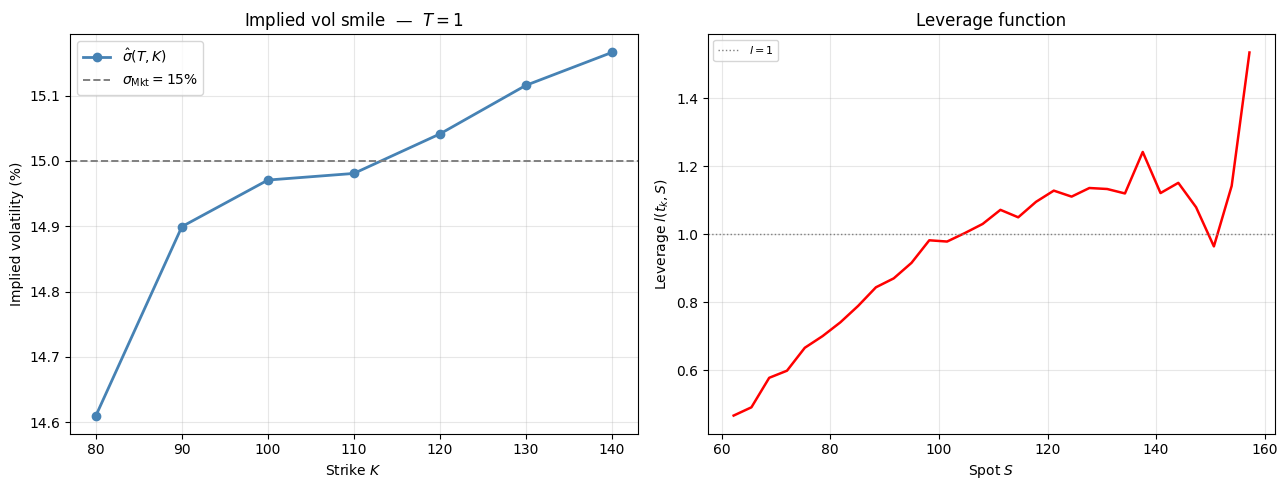

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel 1 : implied vol smile ───────────────────────────────────────────────
ax1.plot(strikes, ivs * 100, 'o-', color='steelblue', lw=2, ms=6,
         label=r'$\hat{\sigma}(T,K)$')
ax1.axhline(sigma_mkt * 100, color='grey', lw=1.4, ls='--',
            label=r'$\sigma_{\mathrm{Mkt}} = 15\%$')
ax1.set_xlabel('Strike $K$')
ax1.set_ylabel('Implied volatility (%)')
ax1.set_title('Implied vol smile  —  $T=1$')
ax1.legend()
ax1.grid(alpha=0.3)

# ── Panel 2 : leverage function ───────────────────────────────────────────────

K_grid = K_grids[max(K_grids.keys())]
l_vals = splines[max(splines.keys())](K_grid)

ax2.plot(K_grid, l_vals, lw=1.8, color='red')
ax2.axhline(1.0, color='grey', lw=1.0, ls=':', label='$l=1$')
ax2.set_xlabel('Spot $S$')
ax2.set_ylabel('Leverage $l(t_k, S)$')
ax2.set_title('Leverage function')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### Question 2

<b>(b).</b> Fix the spot-vol correlation $\rho = 0\%$ and mean reversion $\kappa=1$. We study the impact of volatility of volatility $\gamma$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\gamma$. Suggested values of $\gamma$: $0\%$, $25\%$, $50\%$, $75\%$.
- Recalibrate the leverage function $l(t,S)$ for each $\gamma$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the leverage function on $\gamma$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the smile on $\gamma$.

Parameters : $\gamma$ = 0.0, $\rho$ = 0.0, $\kappa$ = 1.0
CALIBRATION  N=10000  Nt=100
kappa bandwith optimal :0.34
Calibration terminée.

VALIDATION   N=100000

  Strike     Call MC     Call BS      IV hat   Erreur (bp)
----------------------------------------------------------
      70     30.0068     30.0364    12.5352%        +246.5
      80     20.3721     20.4036    14.7267%         +27.3
      90     11.9997     12.0217    14.9253%          +7.5
     100      5.9586      5.9785    14.9499%          +5.0
     110      2.4794      2.5002    14.9388%          +6.1
     120      0.8806      0.8913    14.9484%          +5.2
     130      0.2732      0.2766    14.9643%          +3.6
     140      0.0752      0.0765    14.9654%          +3.5
----------------------------------------------------------
Erreur absolue moyenne : 38.1 bp
Parameters : $\gamma$ = 0.25, $\rho$ = 0.0, $\kappa$ = 1.0
CALIBRATION  N=10000  Nt=100
kappa bandwith optimal :3.00
Calibration terminée.

VALIDATION   N=1

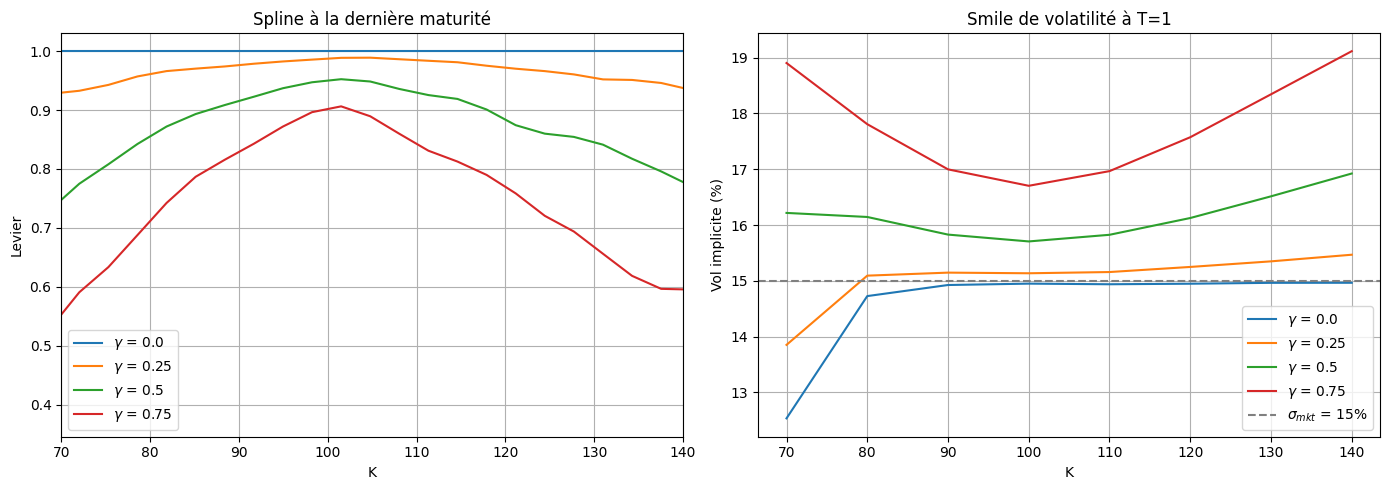

In [ ]:
# ── Paramètres du modèle ──────────────────────────────────────────────
rho     = 0.0
kappa   = 1.0
gammas = np.array([0, 25, 50, 75]) / 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for gamma in gammas:
    print("=" * 60)
    print(f'Parameters : $\\gamma$ = {gamma}, $\\rho$ = {rho}, $\\kappa$ = {kappa}')
    # ── Étape A : Calibration ─────────────────────────────────────────────
    print("=" * 60)
    print(f"CALIBRATION  N={N_calib}  Nt={n_steps}")
    splines, K_grids = particle_method(
        S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
        gamma=gamma, kappa=kappa,
        sigma_mkt=sigma_mkt,
        N=N_calib, n_steps=n_steps, Dt=Dt, seed=42
    )
    print("Calibration terminée.\n")
    K_grid = K_grids[max(K_grids.keys())]
    l_vals = splines[max(splines.keys())](K_grid)

    ax[0].plot(K_grid, l_vals, label=f'$\\gamma$ = {gamma}')

    # ── Étape B : Simulation avec levier calibré ──────────────────────────
    print("=" * 60)
    print(f"VALIDATION   N={N_valid}")
    S_T = simulate_calibrated(
        S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
        gamma=gamma, kappa=kappa,
        sigma_mkt=sigma_mkt,
        N2=N_valid, n_steps=n_steps, Dt=Dt,
        splines=None, K_grids=None, seed=123
    )[-1,:]

    # ── Étape C : Prix des calls et volatilités implicites ────────────────
    print(f"\n{'Strike':>8}  {'Call MC':>10}  {'Call BS':>10}  {'IV hat':>10}  {'Erreur (bp)':>12}")
    print("-" * 58)

    for K in strikes:
        # Prix Monte-Carlo
        call_mc = np.mean(np.maximum(S_T - K, 0))

        # Prix Black-Scholes à sigma_mkt (référence)
        call_bs = blackscholes_price(K=K,T=T,S=S0,vol=sigma_mkt,callput='call')

        # Volatilité implicite
        iv = blackscholes_impv(K=K, T=T, S=S0, value=call_mc, callput='call')
        if np.isnan(iv):
            print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {'  N/A':>10}  {'  N/A':>12}")
        else:
            err_bp = np.abs(iv - sigma_mkt)* 1e4
            print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {iv:>10.4%}  {err_bp:>+12.1f}")

    print("-" * 58)
    ivs = np.array([
        blackscholes_impv(K=K, T=T, S=S0,
                            value=np.mean(np.maximum(S_T - K, 0)),
                            callput='call')
        for K in strikes
    ])
    valid = ~np.isnan(ivs)
    mae_bp = np.mean(np.abs(ivs[valid] - sigma_mkt)) * 1e4
    print(f"Erreur absolue moyenne : {mae_bp:.1f} bp")
    print("=" * 60)

    ax[1].plot(strikes, ivs*100,label=f'$\\gamma$ = {gamma}')

# ── Mise en forme subplot gauche ──────────────────────────────────────
ax[0].set_xlabel('K')
ax[0].set_ylabel('Levier')
ax[0].set_title('Spline à la dernière maturité')
ax[0].set_xlim(70,140)
ax[0].legend()
ax[0].grid()

# ── Mise en forme subplot droite ──────────────────────────────────────
ax[1].set_xlabel('K')
ax[1].set_ylabel('Vol implicite (%)')
ax[1].set_title('Smile de volatilité à T=1')
ax[1].axhline(15, color='grey', linestyle='--', label=r'$\sigma_{mkt}$ = 15%')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()


#### Question 3

<b>(c).</b> Fix the volatility of volatility $\gamma = 50\%$ and mean reversion $\kappa=1$. We study the impact of spot-vol correlation $\rho$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\rho$. Suggested values of $\rho$: $-50\%$, $0\%$, $50\%$.
- Recalibrate the leverage function $l(t,S)$ for each $\rho$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\rho$ in the same graph. Comment on the dependence of the shape of the leverage function on $\rho$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\rho$ in the same graph. Comment on the dependence of the shape of the smile on $\rho$.


Parameters : $\gamma$ = 0.5, $\rho$ = -0.5, $\kappa$ = 1.0
CALIBRATION  N=10000  Nt=100
kappa bandwith optimal :0.91
Calibration terminée.

VALIDATION   N=100000

  Strike     Call MC     Call BS      IV hat   Erreur (bp)
----------------------------------------------------------
      70     30.1566     30.0364    18.4627%        +346.3
      80     20.7556     20.4036    17.5402%        +254.0
      90     12.4627     12.0217    16.4632%        +146.3
     100      6.1824      5.9785    15.5125%         +51.2
     110      2.4122      2.5002    14.7409%         +25.9
     120      0.7444      0.8913    14.2677%         +73.2
     130      0.1904      0.2766    14.0258%         +97.4
     140      0.0429      0.0765    13.9393%        +106.1
----------------------------------------------------------
Erreur absolue moyenne : 137.6 bp
Parameters : $\gamma$ = 0.5, $\rho$ = 0.0, $\kappa$ = 1.0
CALIBRATION  N=10000  Nt=100
kappa bandwith optimal :3.00
Calibration terminée.

VALIDATION   N=

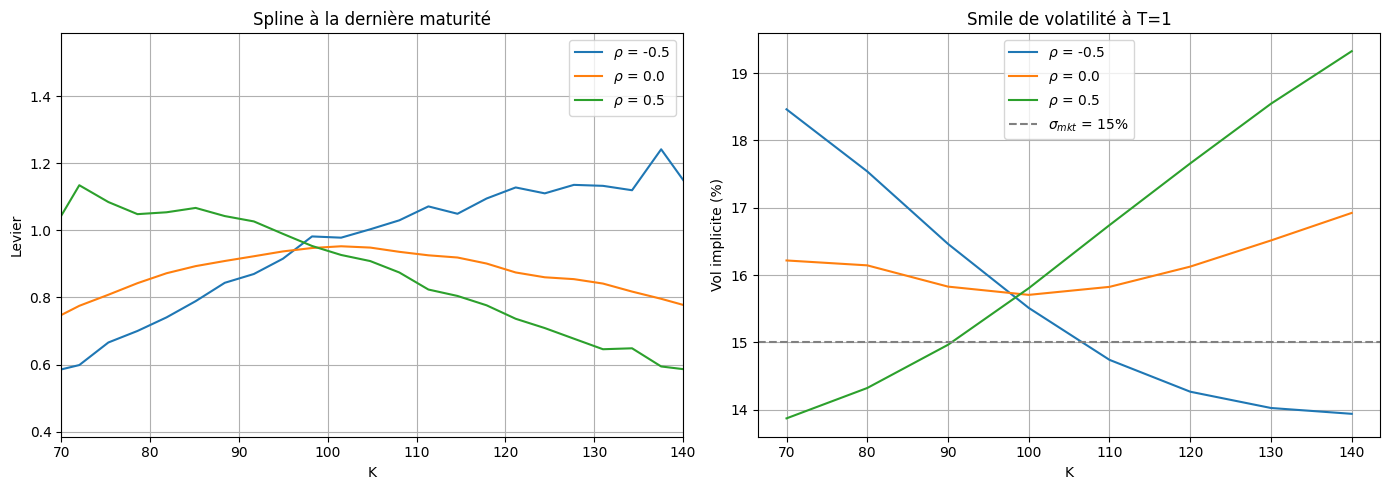

In [ ]:
# ── Paramètres du modèle ──────────────────────────────────────────────
gamma  = 0.50
kappa  = 1.0
rhos = np.array([-50,0,50]) / 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for rho in rhos:
    print("=" * 60)
    print(f'Parameters : $\\gamma$ = {gamma}, $\\rho$ = {rho}, $\\kappa$ = {kappa}')
    # ── Étape A : Calibration ─────────────────────────────────────────────
    print("=" * 60)
    print(f"CALIBRATION  N={N_calib}  Nt={n_steps}")
    splines, K_grids = particle_method(
        S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
        gamma=gamma, kappa=kappa,
        sigma_mkt=sigma_mkt,
        N=N_calib, n_steps=n_steps, Dt=Dt, seed=42
    )

    print("Calibration terminée.\n")
    K_grid = K_grids[max(K_grids.keys())]
    l_vals = splines[max(splines.keys())](K_grid)

    ax[0].plot(K_grid, l_vals, label=f'$\\rho$ = {rho}')

    # ── Étape B : Simulation avec levier calibré ──────────────────────────
    print("=" * 60)
    print(f"VALIDATION   N={N_valid}")
    S_T = simulate_calibrated(
        S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
        gamma=gamma, kappa=kappa,
        sigma_mkt=sigma_mkt,
        N2=N_valid, n_steps=n_steps, Dt=Dt,
        splines=None, K_grids=None, seed=123
    )[-1,:]

    # ── Étape C : Prix des calls et volatilités implicites ────────────────
    print(f"\n{'Strike':>8}  {'Call MC':>10}  {'Call BS':>10}  {'IV hat':>10}  {'Erreur (bp)':>12}")
    print("-" * 58)

    for K in strikes:
        # Prix Monte-Carlo
        call_mc = np.mean(np.maximum(S_T - K, 0))

        # Prix Black-Scholes à sigma_mkt (référence)
        call_bs = blackscholes_price(K=K,T=T,S=S0,vol=sigma_mkt,callput='call')

        # Volatilité implicite
        iv = blackscholes_impv(K=K, T=T, S=S0, value=call_mc, callput='call')
        if np.isnan(iv):
            print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {'  N/A':>10}  {'  N/A':>12}")
        else:
            err_bp = np.abs(iv - sigma_mkt)* 1e4
            print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {iv:>10.4%}  {err_bp:>+12.1f}")

    print("-" * 58)
    ivs = np.array([
        blackscholes_impv(K=K, T=T, S=S0,
                            value=np.mean(np.maximum(S_T - K, 0)),
                            callput='call')
        for K in strikes
    ])
    valid = ~np.isnan(ivs)
    mae_bp = np.mean(np.abs(ivs[valid] - sigma_mkt)) * 1e4
    print(f"Erreur absolue moyenne : {mae_bp:.1f} bp")
    print("=" * 60)

    ax[1].plot(strikes, ivs*100, label=f'$\\rho$ = {rho}')

# ── Mise en forme subplot gauche ──────────────────────────────────────
ax[0].set_xlabel('K')
ax[0].set_ylabel('Levier')
ax[0].set_xlim(70,140)
ax[0].set_title('Spline à la dernière maturité')
ax[0].legend()
ax[0].grid()

# ── Mise en forme subplot droite ──────────────────────────────────────
ax[1].set_xlabel('K')
ax[1].set_ylabel('Vol implicite (%)')
ax[1].set_title('Smile de volatilité à T=1')
ax[1].axhline(15, color='grey', linestyle='--', label=r'$\sigma_{mkt}$ = 15%')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()


The figure above illustrates the impact of the spot-volatility correlation $\rho$ on both the leverage function and the implied volatility smile generated by the uncalibrated model with $l \equiv 1$.

The right panel shows the pure SV smile for each value of $\rho$. For $\rho = -0.5$, the model naturally generates a negatively sloped smile, with higher implied volatilities for low strikes and lower implied volatilities for high strikes, which is the standard negative skew observed in equity markets. Conversely, $\rho = 0.5$ produces a positively sloped smile, while $\rho = 0$ yields a roughly symmetric smile centered near $15\%$, though not perfectly flat due to the convexity effect of stochastic volatility. In all three cases, the uncalibrated smile departs from the flat target $\sigma_{\text{Mkt}} = 15\%$, and it is the role of the leverage function to absorb this residual.

The left panel reveals how $l(t_k, S)$ compensates for each intrinsic smile shape. For $\rho = -0.5$, the leverage function is increasing in $S$, dampening volatility for low spot values and boosting it for high ones, precisely to counteract the negative skew and flatten the smile. For $\rho = 0.5$, the opposite holds: $l(t_k, S)$ is decreasing, suppressing the naturally positive skew. For $\rho = 0$, the leverage function remains close to $1$ across the spot range, reflecting that little correction is needed when the pure SV model already produces a near-flat smile. This confirms that $\rho$ is the primary driver of the skew of the uncalibrated smile, and that the leverage function correctly identifies and inverts its shape in each case.

#### Question 4

<b>(d).</b> Fix the spot-vol correlation $\rho = 0\%$ and volatility of volatility $\gamma = 50\%$. We study the impact of mean reversion $\kappa$ on the smile in the pure stochastic volatility model and calibrated leverage function in the SLV model. Perform the following tasks with various values of $\kappa$. Suggested values of $\kappa$: $0.1$, $1$, $10$.
- Recalibrate the leverage function $l(t,S)$ for each $\gamma$, and plot the calibrated leverage function $l(t, S)$ as a function of the spot value $S$ for a fixed maturity, e.g., $t = T$ with various values of $\gamma$ in the same graph. Comment on the dependence of the shape of the leverage function on $\kappa$.
- Plot the corresponding smile at maturity $T$ for the pure stochastic volatility model (set the leverage function $l \equiv 1$) with the various values of $\kappa$ in the same graph. Comment on the dependence of the shape of the smile on $\kappa$.

Parameters : $\gamma$ = 0.5, $\rho$ = 0.0, $\kappa$ = 0.1
CALIBRATION  N=10000  Nt=100
kappa bandwith optimal :3.00
Calibration terminée.

VALIDATION   N=100000

  Strike     Call MC     Call BS      IV hat   Erreur (bp)
----------------------------------------------------------
      70     30.1253     30.0364    17.8111%        +281.1
      80     20.6779     20.4036    17.0376%        +203.8
      90     12.4392     12.0217    16.3866%        +138.7
     100      6.4391      5.9785    16.1580%        +115.8
     110      2.9756      2.5002    16.3711%        +137.1
     120      1.3195      0.8913    16.8925%        +189.2
     130      0.5942      0.2766    17.5676%        +256.8
     140      0.2753      0.0765    18.2527%        +325.3
----------------------------------------------------------
Erreur absolue moyenne : 206.0 bp
Parameters : $\gamma$ = 0.5, $\rho$ = 0.0, $\kappa$ = 1.0
CALIBRATION  N=10000  Nt=100
kappa bandwith optimal :3.00
Calibration terminée.

VALIDATION   N=1

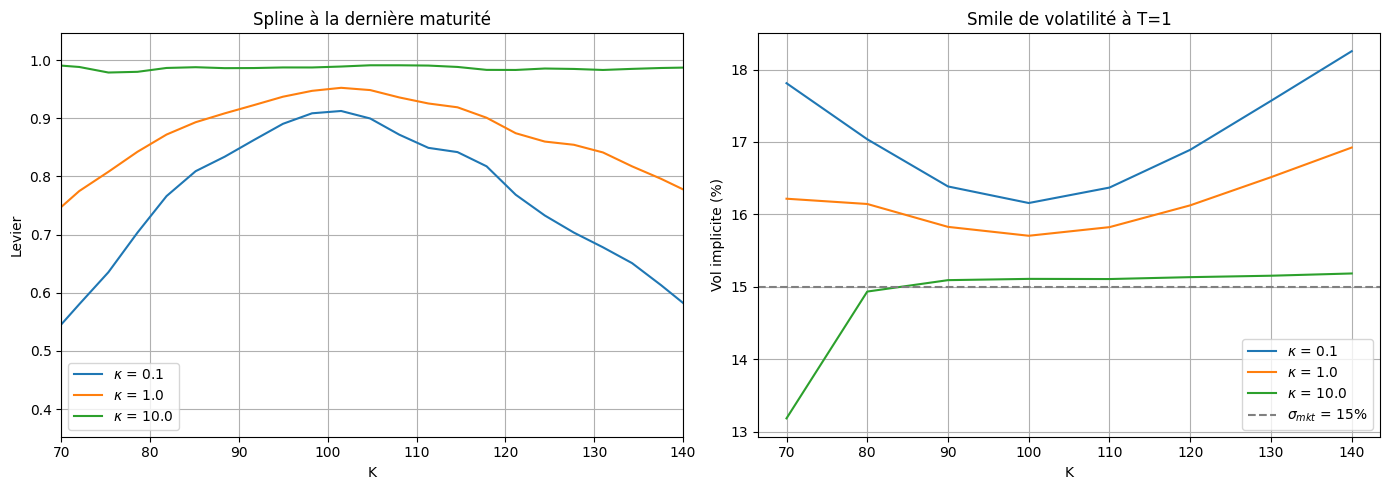

In [ ]:
# ── Paramètres du modèle ──────────────────────────────────────────────
gamma  = 0.50
rho = 0.0
kappas = np.array([0.1, 1, 10])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for kappa in kappas:
    print("=" * 60)
    print(f'Parameters : $\\gamma$ = {gamma}, $\\rho$ = {rho}, $\\kappa$ = {kappa}')
    # ── Étape A : Calibration ─────────────────────────────────────────────
    print("=" * 60)
    print(f"CALIBRATION  N={N_calib}  Nt={n_steps}")
    splines, K_grids = particle_method(
        S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
        gamma=gamma, kappa=kappa,
        sigma_mkt=sigma_mkt,
        N=N_calib, n_steps=n_steps, Dt=Dt, seed=42
    )
    print("Calibration terminée.\n")
    K_grid = K_grids[max(K_grids.keys())]
    l_vals = splines[max(splines.keys())](K_grid)

    ax[0].plot(K_grid, l_vals, label=f'$\\kappa$ = {kappa}')
    # ── Étape B : Simulation avec levier calibré ──────────────────────────
    print("=" * 60)
    print(f"VALIDATION   N={N_valid}")
    S_T = simulate_calibrated(
        S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
        gamma=gamma, kappa=kappa,
        sigma_mkt=sigma_mkt,
        N2=N_valid, n_steps=n_steps, Dt=Dt,
        splines=None, K_grids=None, seed=123
    )[-1,:]

    # ── Étape C : Prix des calls et volatilités implicites ────────────────
    print(f"\n{'Strike':>8}  {'Call MC':>10}  {'Call BS':>10}  {'IV hat':>10}  {'Erreur (bp)':>12}")
    print("-" * 58)

    for K in strikes:
        # Prix Monte-Carlo
        call_mc = np.mean(np.maximum(S_T - K, 0))

        # Prix Black-Scholes à sigma_mkt (référence)
        call_bs = blackscholes_price(K=K,T=T,S=S0,vol=sigma_mkt,callput='call')

        # Volatilité implicite
        iv = blackscholes_impv(K=K, T=T, S=S0, value=call_mc, callput='call')
        if np.isnan(iv):
            print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {'  N/A':>10}  {'  N/A':>12}")
        else:
            err_bp = np.abs(iv - sigma_mkt)* 1e4
            print(f"{K:>8.0f}  {call_mc:>10.4f}  {call_bs:>10.4f}  {iv:>10.4%}  {err_bp:>+12.1f}")

    print("-" * 58)
    ivs = np.array([
        blackscholes_impv(K=K, T=T, S=S0,
                            value=np.mean(np.maximum(S_T - K, 0)),
                            callput='call')
        for K in strikes
    ])
    valid = ~np.isnan(ivs)
    mae_bp = np.mean(np.abs(ivs[valid] - sigma_mkt)) * 1e4
    print(f"Erreur absolue moyenne : {mae_bp:.1f} bp")
    print("=" * 60)

    ax[1].plot(strikes, ivs*100, label=f'$\\kappa$ = {kappa}')

# ── Mise en forme subplot gauche ──────────────────────────────────────
ax[0].set_xlabel('K')
ax[0].set_ylabel('Levier')
ax[0].set_title('Spline à la dernière maturité')
ax[0].set_xlim(70,140)
ax[0].legend()
ax[0].grid()

# ── Mise en forme subplot droite ──────────────────────────────────────
ax[1].set_xlabel('K')
ax[1].set_ylabel('Vol implicite (%)')
ax[1].set_title('Smile de volatilité à T=1')
ax[1].axhline(15, color='grey', linestyle='--', label=r'$\sigma_{mkt}$ = 15%')
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

The figure illustrates the impact of the mean-reversion speed $\kappa$ of the OU process on both the leverage function and the implied volatility smile at maturity $T=1$.

The right panel shows the implied volatility smile generated by the model with $l \equiv 1$, i.e. the pure stochastic volatility model without any leverage correction. This is precisely the smile that the particle method needs to flatten to $\sigma_{\text{Mkt}} = 15\%$, and the left panel shows the resulting leverage function that achieves this.

For $\kappa = 10$, mean-reversion is very fast: the volatility factor $Y_t$ is pulled back to zero almost immediately, so the model behaves nearly like Black-Scholes with constant volatility $\sigma_0$. The pure SV smile is already very close to flat at $15\%$, with a slight U-shape in the wings. Consequently, the leverage function requires almost no correction and remains close to $1$ everywhere.

For $\kappa = 1$, mean-reversion is moderate and the pure SV model generates a more visible symmetric smile, depressed near the money and elevated in the wings. The leverage function responds with a hump-shaped correction peaking near $K = 100$, boosting volatility at the money while damping it in the wings.

For $\kappa = 0.1$, mean-reversion is very slow and volatility shocks are highly persistent, producing a strongly pronounced U-shaped smile with implied volatilities ranging from $13\%$ at low strikes to above $18\%$ in the right wing. The leverage function must apply a large correction across the entire spot range — strongly increasing near the money and sharply decreasing in the wings — to flatten this smile back to $15\%$.

#### Réponse 5

<b>(e).</b> Consider the forward-starting call spread with payoff
$$
\begin{equation*}
50 \left(\left( \frac{S_{T_2}}{S_{T_1}}-0.99 \right)_+ - \left( \frac{S_{T_2}}{S_{T_1}}-1.01 \right)_+\right)
\end{equation*}
$$
with $T_1 = T - \frac{1}{12}$, $T_2 = T$. Use $\gamma = 100\%$, $\rho = -80\%$ and $\kappa=4$. Compare the prices of this option in the Black-Scholes model with volatility 15% and in the calibrated SLV model. Comment on the result. Why is it of interest to use stochastic local volatility models for pricing derivatives?

In [ ]:
T2 = 1.0
T1 = T2 - 1/12
dt = T2 - T1

# Prix BS du forward-starting call spread
# Spot = 1 (ratio normalisé), r=0, q=0
price_bs = 50 * (
    blackscholes_price(K=0.99, T=dt, S=1, vol=0.15, callput='call') -
    blackscholes_price(K=1.01, T=dt, S=1, vol=0.15, callput='call')
)
print(f"Prix BS : {price_bs:.4f}")

# Prix SLV
# Paramètres
gamma  = 1.0
rho    = -0.80
kappa  = 4.0

# Calibration
splines, K_grids = particle_method(
        S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
        gamma=gamma, kappa=kappa,
        sigma_mkt=sigma_mkt,
        N=N_calib, n_steps=n_steps, Dt=Dt, seed=42
    )

# ── Étape B : Simulation avec levier calibré ──────────────────────────
S_paths = simulate_calibrated(
    S0=S0, Y0=Y0, sigma0=sigma0, rho=rho,
    gamma=gamma, kappa=kappa,
    sigma_mkt=sigma_mkt,
    N2=N_valid, n_steps=n_steps, Dt=Dt,
    splines=splines, K_grids=K_grids, seed=123
)

# Prix BS
T2 = 1.0
T1 = T2 - 1/12
dt = T2 - T1

price_bs = 50 * (
    blackscholes_price(K=0.99, T=dt, S=1, vol=0.15, callput='call') -
    blackscholes_price(K=1.01, T=dt, S=1, vol=0.15, callput='call')
)

# Prix SLV
T1_idx = int(round(T1 / Dt))
T2_idx = int(round(T2 / Dt))

ratio = S_paths[T2_idx, :] / S_paths[T1_idx, :]
payoff_slv = 50 * (
    np.maximum(ratio - 0.99, 0) -
    np.maximum(ratio - 1.01, 0)
)
price_slv = np.mean(payoff_slv)

print(f"Prix SLV : {price_slv:.4f}")

Prix BS : 0.4916
kappa bandwith optimal :0.66
Prix SLV : 0.5135


<h3 style="color:deepskyblue">2. Pricing SPX options, VIX futures and VIX options in the two-factor Bergomi model</h3>

The objective of this second part of the computing assignment is to price SPX options, VIX futures, and VIX options in the two-factor Bergomi model

$$
\begin{align*}
S_t &=& S_0 \exp\left(\int_0^t \sqrt{\xi_s^s}dW_s - \frac{1}{2}\int_0^t \xi_s^s ds \right) \\
    X_t^j &=& e^{-k_j t} \int_0^t e^{k_j s} \, dZ^j_s, \qquad j\in\{1,2\} \\
\alpha_\theta &=& \left( (1-\theta)^2 +\theta^2+2 \rho_{12}\theta(1-\theta)\right)^{-1/2} \\
x_t^u &=& \alpha_\theta \left((1-\theta)e^{-k_1(u-t)}X_t^1 + \theta e^{-k_2(u-t)}X_t^2 \right) \\
\xi_t^u &=& \xi_0^u g^u(t,x_t^u) \;\; = \;\;\xi_0^u f^u(t,X_t^1,X_t^2) \\
g^u(t,x) &=& \exp\left(\omega x - \frac{\omega^2}{2}\chi(t,u)\right) \\
\chi(t,u) &=& \alpha_\theta^2\left( (1-\theta)^2e^{-2k_1(u-t)} \text{Var}(X_t^1) + \theta^2e^{-2k_2(u-t)} \text{Var}(X_t^2) \right. \\
&& \left. + 2\theta(1-\theta)e^{-(k_1+k_2)(u-t)}\text{Cov}(X_t^1,X_t^2)\right) \\
d\langle W,Z^1\rangle_t &=& \rho_{S1} dt \\
d\langle W,Z^2\rangle_t &=& \rho_{S2} dt \\
d\langle Z^1,Z^2\rangle_t &=& \rho_{12} dt \\
\end{align*}
$$

In [ ]:
import numpy as np

from scipy.stats import norm
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (4.8, 3.2)

from math import exp, sqrt, log, pi, sin, cos, atan, tan

In [ ]:

try:
    from py_vollib.black_scholes.implied_volatility import implied_volatility
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "py_vollib"])
    from py_vollib.black_scholes.implied_volatility import implied_volatility

vec_find_vol_rat = np.vectorize(implied_volatility)   # a better imp vol estimator based on P Jäckel Let's be rational


## Pricing SPX options

#### Question 2

1. By doing a Cholesky decomposition, give a necessary and sufficient condition (*) on $\rho_{S1},\rho_{S2},\rho_{12}$ so that
$$\begin{bmatrix}1 & \rho_{S1} & \rho_{S2}\\ \rho_{S1} & 1 & \rho_{12} \\ \rho_{S2} & \rho_{12} & 1\end{bmatrix}$$
is a correlation matrix.

<h5 style="color:red"> Réponse </h5>

- Coefficients hors-diagonale dans $[-1, 1]$ : $$|\rho_{S1}| \leq 1, \quad |\rho_{S2}| \leq 1, \quad |\rho_{12}| \leq 1$$

- Symetrique définie-positive (condition de Cholesky) : $$1 - \rho_{S1}^2 - \rho_{S2}^2 - \rho_{12}^2 + 2\rho_{S1}\rho_{S2}\rho_{12} > 0$$


Below we describe a Monte Carlo simulation scheme for the two-factor Bergomi model.

First we discretize the interval $(0,T)$ into subintervals $(t_{i-1}, t_i)$, $1\leq i\leq n$, and set $\Delta t_i=t_i-t_{i-1}$.

The Ornstein-Uhlenbeck process $X^j$ is explicitly solvable:
$$
\begin{equation}
X^j_{t_i}=e^{-k_j\Delta t_i}X^j_{t_{i-1}}+\int_{t_{i-1}}^{t_i} e^{-k_j\left(t_i-s\right)}dZ_s^{j}.
\end{equation}
$$
so that paths of $X^j$ can be simulated exactly.

To simulate the spot process $S$, we use the Euler scheme on the log (by abuse of notation, below, S will denote the Euler scheme, not the true asset price process):
$$\log S_{t_i}-\log S_{t_{i-1}}=-\frac{1}{2}\xi_{t_{i-1}}^{t_{i-1}}\Delta t_i+\sqrt{\xi_{t_{i-1}}^{t_{i-1}}}\int_{t_{i-1}}^{t_i}dW_t$$

Thus given $(S_{t_{i-1}},X^1_{t_{i-1}},X^2_{t_{i-1}})$, $(\log S_{t_i},X^1_{t_i},X^2_{t_i})$ is a Gaussian vector.

#### Question 2

2. Compute the mean vector and covariance matrix of this Gaussian vector.

This is what we will use to iteratively simulate $(\log S_{t_i},X^1_{t_i},X^2_{t_i})$.

<h5 style="color:red"> Réponses </h5>

$$\mathbb{E}[\log S_{t_i}] = \log S_{t_{i-1}} - \frac{1}{2}\xi_{t_{i-1}}^{t_{i-1}} \Delta t_i$$

$$\mathbb{E}[X_{t_i}^j] = e^{-k_j \Delta t_i} X_{t_{i-1}}^j$$

$$\text{Var}(\log S_{t_i}) = \xi_{t_{i-1}}^{t_{i-1}} \Delta t_i$$

$$\text{Var}(X_{t_i}^j) = \frac{1 - e^{-2k_j \Delta t_i}}{2k_j}$$

$$\text{Cov}(\log S_{t_i}, X_{t_i}^j) = \sqrt{\xi_{t_{i-1}}^{t_{i-1}}} \cdot \rho_{Sj} \int_{t_{i-1}}^{t_i} e^{-k_j(t_i - s)} ds = \sqrt{\xi_{t_{i-1}}^{t_{i-1}}} \cdot \rho_{Sj} \cdot \frac{1 - e^{-k_j \Delta t_i}}{k_j}$$

$$\text{Cov}(X_{t_i}^1, X_{t_i}^2) = \rho_{12} \int_{t_{i-1}}^{t_i} e^{-k_1(t_i-s)} e^{-k_2(t_i-s)} ds = \rho_{12} \cdot \frac{1 - e^{-(k_1+k_2)\Delta t_i}}{k_1 + k_2}$$


#### Question 3

3. Fill in the blanks in the code below.


In order to simulate the two-factor Bergomi model, we proceed as follows.

On a uniform grid $t_k = k\Delta t$, the OU processes admit an exact discrete solution. Since $X_t^j = e^{-k_j t}\int_0^t e^{k_j s}dZ_s^j$, the conditional distribution of $X_{t_{k+1}}^j$ given $X_{t_k}^j$ is Gaussian:

$$X_{t_{k+1}}^j \mid X_{t_k}^j \sim N\!\left(e^{-k_j\Delta t}X_{t_k}^j,\;\frac{1-e^{-2k_j\Delta t}}{2k_j}\right)$$

with conditional cross-covariance $\text{Cov}(X_{t_{k+1}}^1, X_{t_{k+1}}^2 \mid X_{t_k}^1, X_{t_k}^2) = \rho_{12}\frac{1-e^{-(k_1+k_2)\Delta t}}{k_1+k_2}$, both implemented via `covar`. This simulation is exact, with no Euler discretisation error on the volatility factors. The instantaneous volatility is then updated as $\sqrt{\xi_{t_{k+1}}^{t_{k+1}}} = \sqrt{\xi_0}\exp\!\left(\frac{\omega}{2}x_{t_{k+1}} - \frac{\omega^2}{4}\chi(t_{k+1})\right)$, where $\chi$ is precomputed on the full time grid before the loop.

At each step, one needs to jointly simulate three correlated Gaussian quantities: the factors $X_{t_{k+1}}^1$, $X_{t_{k+1}}^2$ and the log-return of $S$. Their full $3\times 3$ conditional covariance matrix is

$$\Sigma = \begin{pmatrix} c_{11} & c_{12} & \sigma_{1S} \\ c_{12} & c_{22} & \sigma_{2S} \\ \sigma_{1S} & \sigma_{2S} & \xi_{t_k}\Delta t \end{pmatrix}$$

where $c_{ij} = \text{Cov}(X_{t_{k+1}}^i, X_{t_{k+1}}^j \mid X_{t_k}^i, X_{t_k}^j)$ are the conditional OU covariances and $\sigma_{jS} = \sqrt{\xi_{t_k}}\,\rho_{Sj}\,\frac{1-e^{-k_j\Delta t}}{k_j}$ is the conditional cross-covariance between $X_{t_{k+1}}^j$ and the log-return, implemented in `cov_s_xj`. For $\Sigma$ to be positive definite, the necessary and sufficient condition

$$1 - \rho_{S1}^2 - \rho_{S2}^2 - \rho_{12}^2 + 2\rho_{S1}\rho_{S2}\rho_{12} > 0$$

is checked explicitly before the simulation loop. The Cholesky factorisation $\Sigma = LL^\top$ is then computed analytically. The $2\times 2$ block for the OU factors gives

$$l_{11} = \sqrt{c_{11}}, \qquad l_{21} = \frac{c_{12}}{l_{11}}, \qquad l_{22} = \sqrt{c_{22} - l_{21}^2}$$

and the third row corresponding to the log-return gives

$$l_{31} = \frac{\sigma_{1S}}{l_{11}}, \qquad l_{32} = \frac{\sigma_{2S} - l_{31}l_{21}}{l_{22}}, \qquad l_{33} = \sqrt{\xi_{t_k}\Delta t - l_{31}^2 - l_{32}^2}$$

Note that $l_{11}, l_{21}, l_{22}$ are constant and precomputed once before the loop, while $l_{31}, l_{32}, l_{33}$ depend on $\xi_{t_k}$ and are recomputed at each step. Given three independent standard normal draws $(z_1, z_2, z_3)$, the joint update then reads

$$X_{t_{k+1}}^1 = e^{-k_1\Delta t}X_{t_k}^1 + l_{11}\,z_1$$

$$X_{t_{k+1}}^2 = e^{-k_2\Delta t}X_{t_k}^2 + l_{21}\,z_1 + l_{22}\,z_2$$

$$\ln S_{t_{k+1}} = \ln S_{t_k} - \frac{1}{2}\xi_{t_k}\Delta t + l_{31}z_1 + l_{32}z_2 + l_{33}z_3$$

The residual term $l_{33}z_3$ captures the component of spot risk that is orthogonal to both volatility factors, that is the part of $dW$ not explained by $dZ^1$ or $dZ^2$.

In [ ]:
def two_factor_bergomi_mc(T, vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2, xi_0, S_0, n_steps, N_sims, seed=42):
    """
    Monte Carlo simulation of the two-factor Bergomi forward variance model.

    Parameters
    ----------
    T : float
        Maturity (years).
    vov : float
        Vol-of-vol omega; controls the lognormal volatility of xi.
    k_1 : float
        Mean-reversion speed of the short OU factor X^1.
    k_2 : float
        Mean-reversion speed of the long OU factor X^2 (k_2 < k_1).
    theta : float
        Mixing weight in [0, 1]; weight on the long factor X^2.
    rho_sx1 : float
        Correlation between spot W and short factor Z^1.
    rho_sx2 : float
        Correlation between spot W and long factor Z^2.
    rho_x1x2 : float
        Correlation between the two OU factors Z^1 and Z^2.
    xi_0 : float
        Initial flat forward variance curve; ATM vol = sqrt(xi_0).
    S_0 : float
        Initial spot price.
    n_steps : int
        Number of time steps.
    N_sims : int
        Number of Monte Carlo paths.
    seed : int, optional
        Random seed for reproducibility. Default is 42.

    Returns
    -------
    S_T : ndarray of shape (N_sims,)
        Simulated terminal spot values S_T.

    Raises
    ------
    ValueError
        If the correlation matrix is not positive definite, i.e. if
        1 - rho_sx1^2 - rho_sx2^2 - rho_x1x2^2 + 2*rho_sx1*rho_sx2*rho_x1x2 <= 0.
    """

    np.random.seed(seed)
    dt = T / n_steps

    def covar(k_1, k_2, rho, t):
        return rho * (1 - np.exp(-(k_1 + k_2) * t)) / (k_1 + k_2)

    def cov_s_xj(kj, rho_sj, xi, dt):
        return np.sqrt(xi) * rho_sj * (1 - np.exp(-kj * dt)) / kj

    def chi_func(k_1, k_2, theta, rho_x1x2, alpha, t):
        chi = ((1 - theta)**2 * covar(k_1, k_1, 1.0, t)
             +      theta**2  * covar(k_2, k_2, 1.0, t)
             + 2 * theta * (1 - theta) * covar(k_1, k_2, rho_x1x2, t))
        return alpha**2 * chi

    alpha = 1 / sqrt((1 - theta)**2 + theta**2 + 2 * rho_x1x2 * theta * (1 - theta))
    tt  = np.linspace(0., T, n_steps + 1)
    chi = chi_func(k_1, k_2, theta, rho_x1x2, alpha, tt)

    # ------------------------------------------------------------------
    # Cholesky
    l11 = sqrt(covar(k_1, k_1, 1.0,      dt))
    l21 = covar(k_1, k_2, rho_x1x2, dt) / l11
    l22 = sqrt(covar(k_2, k_2, 1.0, dt) - l21**2)

    X_1      = np.zeros((n_steps + 1, N_sims))
    X_2      = np.zeros((n_steps + 1, N_sims))
    X        = np.zeros((n_steps + 1, N_sims))
    inst_vol = np.zeros((n_steps + 1, N_sims))
    logS     = np.zeros((n_steps + 1, N_sims))

    logS[0]     = log(S_0)
    inst_vol[0] = sqrt(xi_0)
    # Check positive definiteness of the full 3x3 correlation matrix
    det = 1 - rho_sx1**2 - rho_sx2**2 - rho_x1x2**2 \
        + 2 * rho_sx1 * rho_sx2 * rho_x1x2

    if det <= 0:
        raise ValueError("Invalid correlation matrix (Cholesky fails)")

    for i in range(n_steps):

        z1, z2, z3 = np.random.normal(size=(3, N_sims))

        # --- Facteurs OU ---
        X_1[i+1] = X_1[i] * np.exp(-k_1 * dt) + l11 * z1
        X_2[i+1] = X_2[i] * np.exp(-k_2 * dt) + l21 * z1 + l22 * z2
        X[i+1]   = alpha * ((1 - theta) * X_1[i+1] + theta * X_2[i+1])
        inst_vol[i+1] = sqrt(xi_0) * np.exp(vov/2 * X[i+1] - vov**2/4 * chi[i+1])

        xi_i = inst_vol[i]**2

        c1S = cov_s_xj(k_1, rho_sx1, xi_i, dt)
        c2S = cov_s_xj(k_2, rho_sx2, xi_i, dt)

        l31 = c1S / l11
        l32 = (c2S - l31 * l21) / l22
        l33 = np.sqrt(xi_i * dt - l31**2 - l32**2)

        logS[i+1] = logS[i] - 0.5 * xi_i * dt + l31 * z1 + l32 * z2 + l33 * z3

    return np.exp(logS[-1])

In [ ]:
vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1,rho_sx2,rho_x1x2 = -0.8, -0.7, 0.7
T = 1
S_0 = 100
n_steps = 500
N_sims = 10_000

ST = two_factor_bergomi_mc(T,vov,k_1,k_2,theta,rho_sx1, rho_sx2, rho_x1x2,xi_0,S_0,n_steps,N_sims)

lm = np.linspace(-0.6,0.4,100) # log-moneyness
strike_array = np.exp(lm)*S_0

opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
iv = vec_find_vol_rat(opt_price, S_0, strike_array, T, 0, 'c')

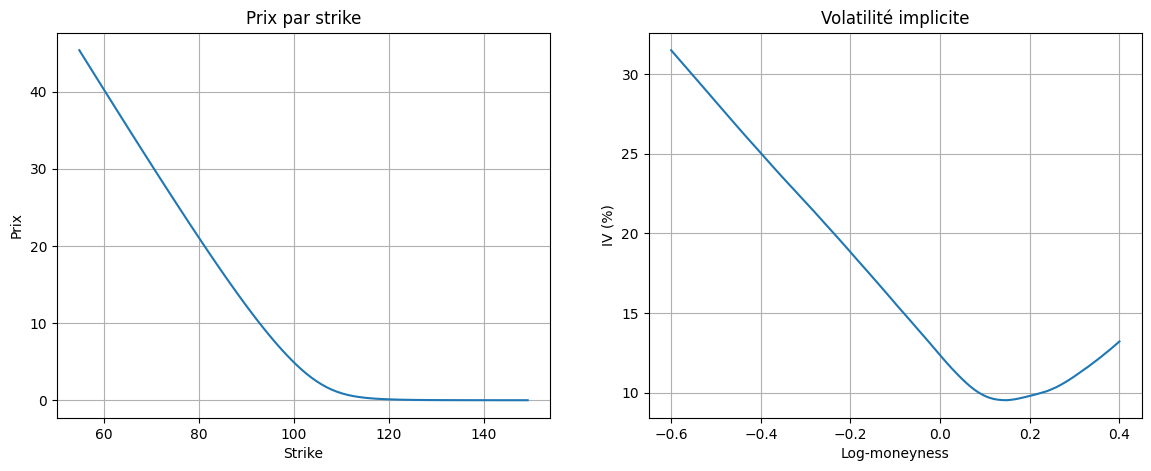

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(strike_array, opt_price)
ax[0].grid()
ax[0].set_title("Prix par strike")
ax[0].set_xlabel("Strike")
ax[0].set_ylabel("Prix")


ax[1].plot(lm, iv*100)
ax[1].grid()
ax[1].set_title("Volatilité implicite")
ax[1].set_xlabel("Log-moneyness")
ax[1].set_ylabel("IV (%)")

plt.show()

# Question 4
4. Vary the parameters vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2 and T and comment on the impact on the SPX smile.

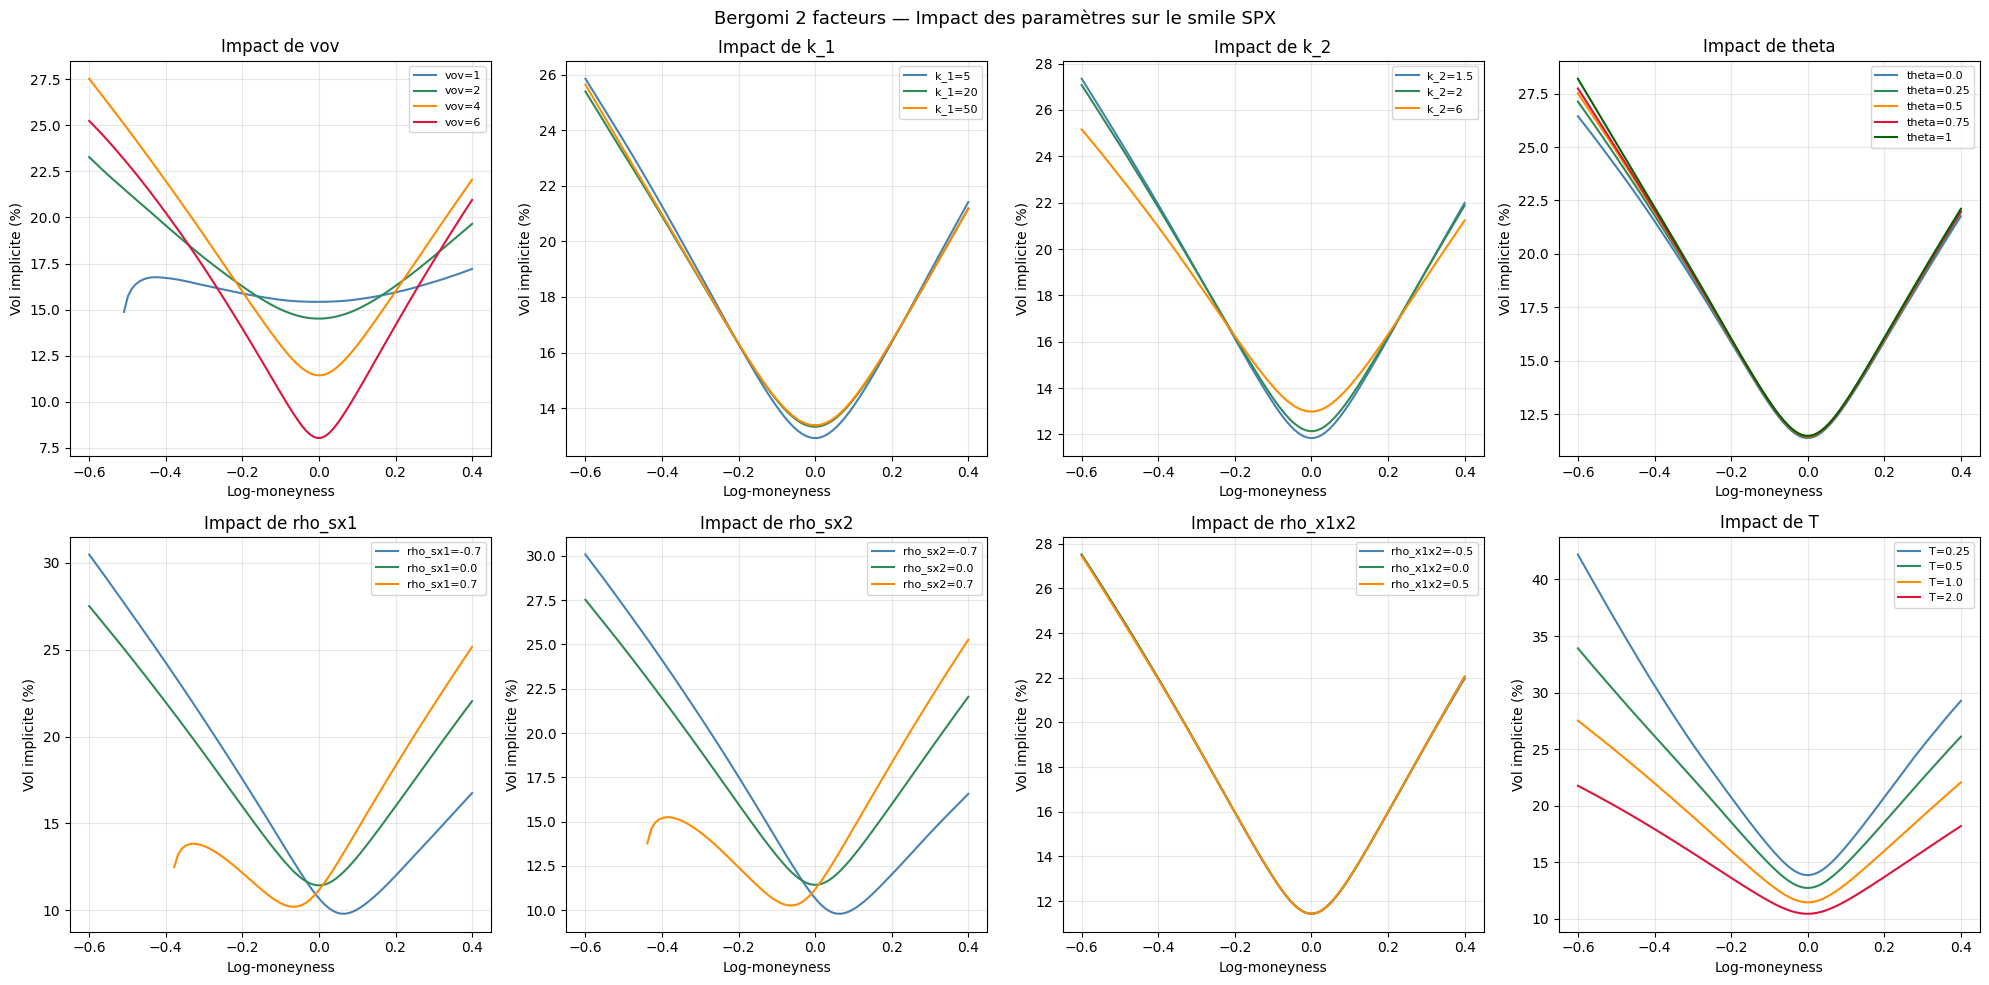

In [ ]:
def compute_smile(vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2,
                  xi_0, S0, n_steps, N_sims, T,
                  lm=np.linspace(-0.6, 0.4, 100)):
    np.random.seed(42)
    ST = two_factor_bergomi_mc(T,vov, k_1, k_2, theta, rho_sx1,
                                         rho_sx2, rho_x1x2, xi_0, S0,
                                         n_steps, N_sims)
    strike_array = np.exp(lm) * S0
    opt_price = np.average(np.maximum(ST-strike_array.reshape(-1,1),0),axis=1)
    iv = np.full(len(lm), np.nan)
    for i, (p, K) in enumerate(zip(opt_price, strike_array)):
        try:
            iv[i] = vec_find_vol_rat(p, S0, K, T, 0, 'c')
        except Exception:
            pass   # laisse NaN

    return iv

def get_iv(vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2, xi_0, S0, n_steps, N_sims, T, lm=np.linspace(-0.6, 0.4, 100)):
    np.random.seed(42)
    K_plot = np.exp(lm) * S0
    S_T = two_factor_bergomi_mc(T,vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2, xi_0, S0, n_steps, N_sims)
    prices = np.array([np.mean(np.maximum(S_T - K, 0)) for K in K_plot])
    return blackscholes_impv(K=K_plot, T=T, S=S0, value=prices)

# Paramètres de base
base = dict(vov=4, k_1=1, k_2=1, theta=0.5,
            rho_sx1=0, rho_sx2=0, rho_x1x2=0,
            xi_0=0.025, S0=100, n_steps=500, N_sims=100000, T=1)

lm = np.linspace(-0.6, 0.4, 100)

variations = {
    'vov' : [1,2,4,6],
    'k_1': [5, 20, 50],
    'k_2' : [1.5, 2, 6],
    'theta' : [0.0, 0.25, 0.5, 0.75, 1],
    'rho_sx1'  : [-0.70, 0.0, 0.70],
    'rho_sx2'  : [-0.70, 0.0, 0.70],
    'rho_x1x2' : [-0.50, 0.0, 0.50],
    'T'        : [0.25, 0.5, 1.0, 2.0],
}

colors = ['steelblue', 'seagreen', 'darkorange', 'crimson', 'darkgreen', 'purple']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, (param, values) in zip(axes.flatten(), variations.items()):
    for val, color in zip(values, colors):
        params = {**base, param: val}
        iv = compute_smile(**params, lm=lm)
        ax.plot(lm, iv * 100, color=color, linewidth=1.5, label=f'{param}={val}')

    ax.set_title(rf'Impact de {param}')
    ax.set_xlabel('Log-moneyness')
    ax.set_ylabel('Vol implicite (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Bergomi 2 facteurs — Impact des paramètres sur le smile SPX', fontsize=13)
plt.tight_layout()
plt.show()

Afin d'évaluer l'impact des paramètres vov, k_1, k_2, theta, rho_sx1, rho_sx2, rho_x1x2 and T sur le smile de volatilité, nous considérons les paramètres de base suivants:

- $\omega$=4
- $k_1$=1
- $k_2$=1
- $\theta$=0.5, pour donner la même importance aux deux facteurs du modèle.
- $\rho_{sx1}$=0
- $\rho_{sx2}$=0
- $\rho_{x1x2}$=0
- $T=1$

Chacun de ces paramètres est ensuite varié, toute chose égale par ailleurs.
We can see that:

- **\omega (vol-of-vol):** Increasing ω steepens and widens the smile (more curvature and higher wings). This is because larger ω means the instantaneous variance $\xi_t^t$ fluctuates more, adding kurtosis and skewness to the terminal distribution.

- **$k_1$ (fast factor mean-reversion):** $k_1$ controls the speed of the short-term vol factor. Larger $k_1$ reduces its impact on the smile (vol reverts faster), producing a flatter smile. The short-term factor mainly affects the shape at short maturities.
**$k_2$ (fast factor mean-reversion):** $k_2$ controls the speed of the long-term vol factor. .

- **\rho_{S1}, \rho_{S2} (spot-vol correlations):** These control the skew. More negative correlations produce a steeper negative skew (higher vol for OTM puts), consistent with the empirical equity premium. At $\rho=0$, the smile is nearly symmetric.

- **\theta (mixing weight)** controls the balance between the two factors. $\theta=0$ is a one-factor model driven by $X_1$ (fast reversion), $\theta=1$ uses only $X_2$ (slow reversion). Intermediate $\theta$ allows the model to fit both short-term and long-term term structure of skew simultaneously.

- **T (maturity):** The smile flattens at longer maturities (skew decays roughly as $\dfrac{1}{\sqrt{T}}$ at long horizons). The curvature also decreases. This is consistent with empirical observations.

- **$\rho_{12}$ (factor correlation):** Controls how the two vol factors move together. Higher $\rho_{12}$ makes them more correlated, effectively reducing the model to a single factor and flattening the term structure of the smile.

## Pricing VIX futures and VIX options

# Question 5

5. Prove that $(\xi_t^u)_{t\in[0,u]}$ is a martingale in $t$, for fixed $u>0$.

<h5 style="color:red"> Proof </h5>
Let $0 \leq s \leq t \leq u$ and recall that

$$\xi_t^u = \xi_0^u \exp\left(\omega x_t^u - \frac{\omega^2}{2}\chi(t,u)\right).$$

Since $x_t^u$ is $F_t$-measurable, the process $(\xi_t^u)_{t\in[0,u]}$ is adapted. Moreover, $x_t^u$ is a centred Gaussian with variance $\chi(t,u)$, so by the moment generating function of a Gaussian,

$$\mathbb{E}\left[e^{\omega x_t^u}\right] = e^{\frac{\omega^2}{2}\chi(t,u)}$$

which gives $\mathbb{E}[\xi_t^u] = \xi_0^u < \infty$, so $\xi_t^u \in L^1$.

To establish the martingale property, write $x_t^u = x_s^u + (x_t^u - x_s^u)$, so that

$$\xi_t^u = \xi_0^u \exp\left(\omega x_s^u + \omega(x_t^u - x_s^u) - \frac{\omega^2}{2}\chi(t,u)\right).$$

Since $x_t^u$ is a linear combination of OU processes driven by independent Brownian motions, it has independent increments. Therefore $x_t^u - x_s^u$ is independent of $F_s$ and centred Gaussian with variance $\chi(t,u) - \chi(s,u)$, which gives

$$\mathbb{E}\left[e^{\omega(x_t^u - x_s^u)} \mid F_s\right] = e^{\frac{\omega^2}{2}(\chi(t,u)-\chi(s,u))}.$$

Taking the conditional expectation with respect to $F_s$ and using that $x_s^u$ is $F_s$-measurable,

$$\mathbb{E}[\xi_t^u \mid F_s] = \xi_0^u\, e^{\omega x_s^u - \frac{\omega^2}{2}\chi(t,u)} \cdot e^{\frac{\omega^2}{2}(\chi(t,u)-\chi(s,u))} = \xi_0^u\, e^{\omega x_s^u - \frac{\omega^2}{2}\chi(s,u)} = \xi_s^u.$$

Hence $(\xi_t^u)_{t\in[0,u]}$ is a martingale.


# Question 6


6. Denote $\sigma_t^2 = \xi_t^t$. Prove that $\xi_T^u = \mathbb{E}[\sigma_u^2|\mathcal{F}_T]$ and deduce that
$$\text{VIX}^2_T = \frac{1}{\tau}\int_T^{T+\tau} \xi_T^u du$$
where $\tau=30/365$ (30 days). Prove that, as a result, in the two-factor Bergomi model, there exists a function $\psi$ such that
$$\text{VIX}_T = \psi(T,X_T^1,X_T^2)$$
and write down the function $\psi$.


<h5 style="color:red"> Réponse </h5>

On a, par définition, $\sigma_t^2 = \xi_t^t.$
D'après la question précédente, pour tout $u>0$, le processus $(\xi_t^u)_{t\in[0,u]}$ est une martingale. Ainsi, si $T \leq u$,
$\mathbb{E}[\xi_u^u \mid \mathcal{F}_T] = \xi_T^u$. Or $\xi_u^u = \sigma_u^2$, donc $\xi_T^u = \mathbb{E}[\sigma_u^2 \mid \mathcal{F}_T]$.

Par définition,$\mathrm{VIX}_T^2 = \frac{1}{\tau}\,\mathbb{E}\left[\int_T^{T+\tau}\sigma_u^2\,du \,\middle|\, \mathcal{F}_T\right], \qquad \tau=\frac{30}{365}$.

En utilisant Fubini conditionnel,
$$
\begin{align*}
\mathrm{VIX}_T^2
&= \frac{1}{\tau}\int_T^{T+\tau}\mathbb{E}[\sigma_u^2 \mid \mathcal{F}_T] du \\
&= \frac{1}{\tau}\int_T^{T+\tau}\xi_T^u du \qquad \text{car } \mathbb{E}[\sigma_u^2 \mid \mathcal{F}_T]=\xi_T^u
\end{align*}
$$

Dans le modèle de Bergomi à deux facteurs, on écrit $ \xi_t^u = \xi_0^u g^u(t,x_t^u) \;\; = \;\;\xi_0^u f^u(t,X_t^1,X_t^2)$.

Par conséquent, $\mathrm{VIX}_T$ dépend seulement de $T$, $X_T^1$ et $X_T^2$, et il existe une fonction $\psi$ telle que
$$
\mathrm{VIX}_T = \psi(T,X_T^1,X_T^2).
$$

Cette fonction est donnée par
$$
\psi(T,x_1,x_2)
=
\left(
\frac{1}{\tau}\int_T^{T+\tau}
\xi_0^u
\exp\left(
\omega \alpha\left(
(1-\theta)e^{-k_1(u-T)}x_1
+ \theta e^{-k_2(u-T)}x_2
\right)
- \frac{\omega^2}{2}\chi(T,u)
\right)\,du
\right)^{1/2}.
$$

Since the vector $(X_T^1,X_T^2)$ is Gaussian, the price $\mathbb{E}[h(\text{VIX}_T)]$ of a VIX option $h(\text{VIX}_T)$ can very efficiently be estimated by a Gauss-Hermite quadrature; see
https://en.wikipedia.org/wiki/Gaussian_quadrature and
https://numpy.org/doc/stable/reference/generated/numpy.polynomial.hermite.hermgauss.html

# Question 6
Using this method, price a VIX future maturing at $T$ (choose $T=1/12$ (1 month), $2/12$, $3/12$, $4/12$) and VIX call options with the same maturity; take strikes with log-moneyness from -0.2 to 2.5, based on the price of the VIX future. Vary the number of points in the quadrature: 10, 20, 30, 50. What do you observe? Using 50 points in the quadrature, plot the VIX smile, using the Black formula (with spot value the value of the VIX future) to compute the VIX implied volatilities.

In [ ]:
from scipy.integrate import quad
import numpy as np

vov = 4
k_1 = 20
k_2 = 1.5
theta = 0.75
xi_0 = 0.025
rho_sx1, rho_sx2, rho_x1x2 = -0.8, -0.7, 0.7
T = 1
S_0 = 100
n_steps = 500
N_sims = 10_000

def psi(T, x1, x2, tau, omega, theta, k1, k2, xi0, var_X1, var_X2, rho12):
    cov_X12 = rho12 * np.sqrt(var_X1 * var_X2)
    alpha_sq = (1 - theta)**2 + theta**2 + 2 * rho12 * theta * (1 - theta)
    alpha = alpha_sq ** (-0.5)

    def integrand(u):
        d = u - T
        chi = alpha_sq * (
            (1 - theta)**2 * np.exp(-2 * k1 * d) * var_X1
            + theta**2     * np.exp(-2 * k2 * d) * var_X2
            + 2 * theta * (1 - theta) * np.exp(-(k1 + k2) * d) * cov_X12
        )

        x_u = alpha * (
            (1 - theta) * np.exp(-k1 * d) * x1
            + theta     * np.exp(-k2 * d) * x2
        )
        exponent = omega * x_u - (omega**2 / 2) * chi
        return xi0 * np.exp(exponent)

    integral, _ = quad(integrand, T, T + tau)
    avg = integral / tau

    return float(np.sqrt(avg))

def gaussian_quad(T, tau, omega, theta, k1, k2, xi0,
                     rho12, n_gh=10, h=None):
    """
    Calcule E[h(psi)] par quadrature de Gauss-Hermite 2D.
    Si h=None, calcule simplement E[psi].
    Exemple : h = lambda x: x**2  pour E[psi²]
              h = lambda x: np.maximum(x - K, 0)  pour un call
    """
    if h is None:
        h = lambda x: x

    xi_gh, w_gh = np.polynomial.hermite.hermgauss(n_gh)

    def covar(k_a, k_b, rho, t):
        return rho * (1 - np.exp(-(k_a + k_b) * t)) / (k_a + k_b)

    var_X1  = covar(k1, k1, 1.0, T)
    var_X2  = covar(k2, k2, 1.0, T)
    l11 = np.sqrt(var_X1)
    l21 = covar(k1, k2, rho12, T) / l11
    l22 = np.sqrt(var_X2 - l21**2)
    total = 0.0
    for i in range(n_gh):
        for j in range(n_gh):
            x1 = np.sqrt(2) * xi_gh[i] * l11
            x2 = np.sqrt(2) * (l21 * xi_gh[i] + l22 * xi_gh[j])

            val = psi(T, x1, x2, tau, omega, theta, k1, k2, xi0,
                      var_X1, var_X2, rho12)

            total += w_gh[i] * w_gh[j] * h(val)

    return total / np.pi

     T (m) |      n_gh=10 |      n_gh=20 |      n_gh=30 |      n_gh=50
--------------------------------------------------------------------
         1 | 0.1496 | 0.1496 | 0.1496 | 0.1496
         2 | 0.1435 | 0.1435 | 0.1435 | 0.1435
         3 | 0.1390 | 0.1390 | 0.1390 | 0.1390
         4 | 0.1355 | 0.1355 | 0.1355 | 0.1355

=== Futures VIX (n_gh=50) ===
T=1/12 : F = 0.149617
T=2/12 : F = 0.143520
T=3/12 : F = 0.138956
T=4/12 : F = 0.135528


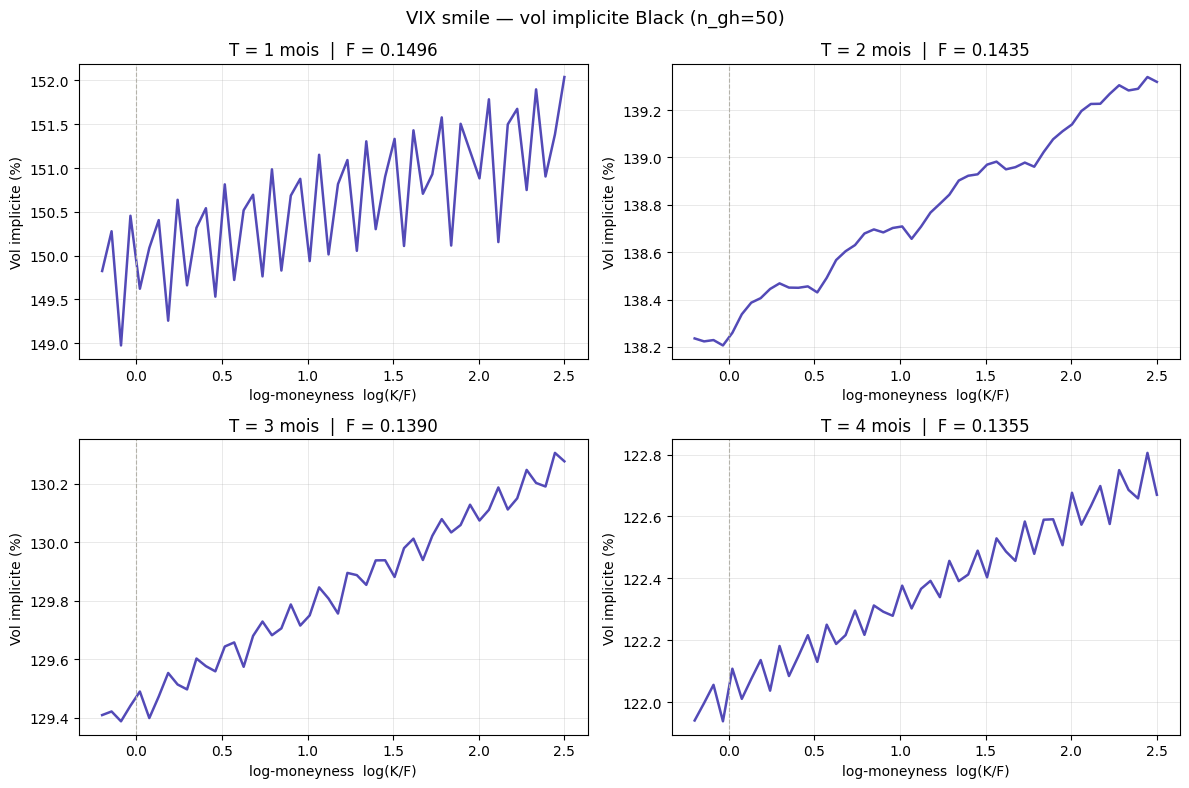

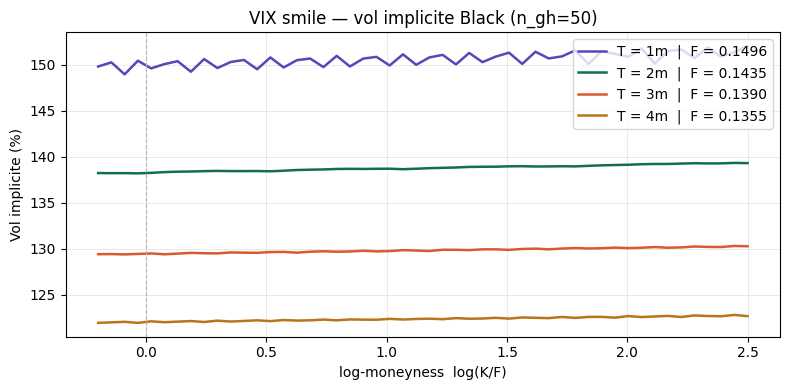

In [ ]:
from py_vollib.black_scholes.implied_volatility import implied_volatility
import numpy as np
import matplotlib.pyplot as plt

vec_find_vol_rat = np.vectorize(implied_volatility)

# ── Paramètres ────────────────────────────────────────────────────────────────
vov      = 4
k_1      = 20
k_2      = 1.5
theta    = 0.75
xi_0     = 0.025
rho_x1x2 = 0.7
tau      = 1/12

maturities  = [1/12, 2/12, 3/12, 4/12]
n_gh_values = [10, 20, 30, 50]
lm_grid     = np.linspace(-0.2, 2.5, 50)
# ── Helpers
def compute_future(T, n_gh=50):
    return gaussian_quad(T, tau, vov, theta, k_1, k_2, xi_0,
                         rho_x1x2, n_gh=n_gh, h= lambda x: x)

def compute_call_prices(T, F, n_gh=50):
    strikes = F * np.exp(lm_grid)
    prices = np.array([
        gaussian_quad(T, tau, vov, theta, k_1, k_2, xi_0,
                      rho_x1x2, n_gh=n_gh,
                      h=lambda x, K=K: np.maximum(x - K, 0.0))
        for K in strikes
    ])
    return prices, strikes

def black_iv(prices, F, T, lm):
    strikes = F * np.exp(lm)
    iv = np.full(len(lm), np.nan)
    for i, (p, K) in enumerate(zip(prices, strikes)):
        try:
             iv[i] = vec_find_vol_rat(price=p, S=F, K=K, t=T, r=0, flag='c')
        except Exception:
            pass
    return iv

# ── 1. Convergences
print(f"{'T (m)':>10} | {'n_gh=10':>12} | {'n_gh=20':>12} | {'n_gh=30':>12} | {'n_gh=50':>12}")
print("-" * 68)
for T in maturities:
    vals = [compute_future(T=T, n_gh=n) for n in n_gh_values]
    print(f"{T*12:>10.0f} | " + " | ".join(f"{v:>.4f}" for v in vals))

# ── 2. Futures par maturité (n_gh=50) ────────────────────────────────────────
futures = {T: compute_future(T) for T in maturities}
print("\n=== Futures VIX (n_gh=50) ===")
for T, F in futures.items():
    print(f"T={T*12:.0f}/12 : F = {F:.6f}")

# ── 3. Smiles (n_gh=50) ───────────────────────────────────────────────────────
smile_data = {}
for T in maturities:
    F = futures[T]
    prices, _ = compute_call_prices(T, F)
    smile_data[T] = black_iv(prices, F, T, lm_grid)

# ── Figure 1 : one panel per maturity
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, T in enumerate(maturities):
    ax = axes.flatten()[idx]
    ax.plot(lm_grid, smile_data[T] * 100, color='#534AB7', linewidth=1.8)
    ax.axvline(0, color='#B4B2A9', linewidth=0.8, linestyle='--')
    ax.set_title(f"T = {T*12:.0f} mois  |  F = {futures[T]:.4f}")
    ax.set_xlabel("log-moneyness  log(K/F)")
    ax.set_ylabel("Vol implicite (%)")
    ax.grid(True, linewidth=0.4, alpha=0.5)
fig.suptitle("VIX smile — vol implicite Black (n_gh=50)", fontsize=13)
plt.tight_layout()
plt.show()

# ── Figure 2 : all maturities on the same axes
colors = ['#534AB7', '#0F6E56', '#D85A30', '#BA7517']

fig, ax = plt.subplots(figsize=(8, 4))
for idx, T in enumerate(maturities):
    ax.plot(lm_grid, smile_data[T] * 100, color=colors[idx], linewidth=1.8,
            label=f"T = {T*12:.0f}m  |  F = {futures[T]:.4f}")
ax.axvline(0, color='#B4B2A9', linewidth=0.8, linestyle='--')
ax.set_xlabel("log-moneyness  log(K/F)")
ax.set_ylabel("Vol implicite (%)")
ax.set_title("VIX smile — vol implicite Black (n_gh=50)")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()


At this step, we apply the method describe in [P. Jäckel](#1) for quadrature using Gauss-Hermite points and Cholesky decomposition.

**Quadrature convergence:** The VIX futures prices converge rapidly with the number of Gauss-Hermite points. With as few as 10 points, the estimates are within <0.01% of the 50-point results, demonstrating the efficiency of the quadrature method exploiting the Gaussian structure of $(X_T^1, X_T^2)$.

**VIX smile:** The VIX smile shows a pronounced positive skew (upward slope), especially for short maturities. This reflects the fact that VIX options are typically OTM calls (investors buy upside VIX protection against vol spikes). The smile flattens at longer maturities as the distribution of the VIX becomes less skewed. The strong vol-of-vol ($\omega=4$) produces a wide, steep smile consistent with observed VIX option markets.

# Question 7

Comment on the impact of the vol-of-vol on the price of the VIX future and on the VIX implied volatilities. In the one-factor Bergomi model ($\theta=0$), comment on the impact of the mean reversion on the VIX implied volatilities: take $k_1 = 1,5,10,30,60,100$.

=== Impact du vol-of-vol sur le future VIX ===
     vov |       T=1m |       T=2m |       T=3m |       T=4m
----------------------------------------------------------
     1.0 | 0.1576 | 0.1572 | 0.1568 | 0.1566
     2.0 | 0.1559 | 0.1543 | 0.1531 | 0.1521
     4.0 | 0.1496 | 0.1435 | 0.1390 | 0.1355
     6.0 | 0.1397 | 0.1272 | 0.1183 | 0.1119


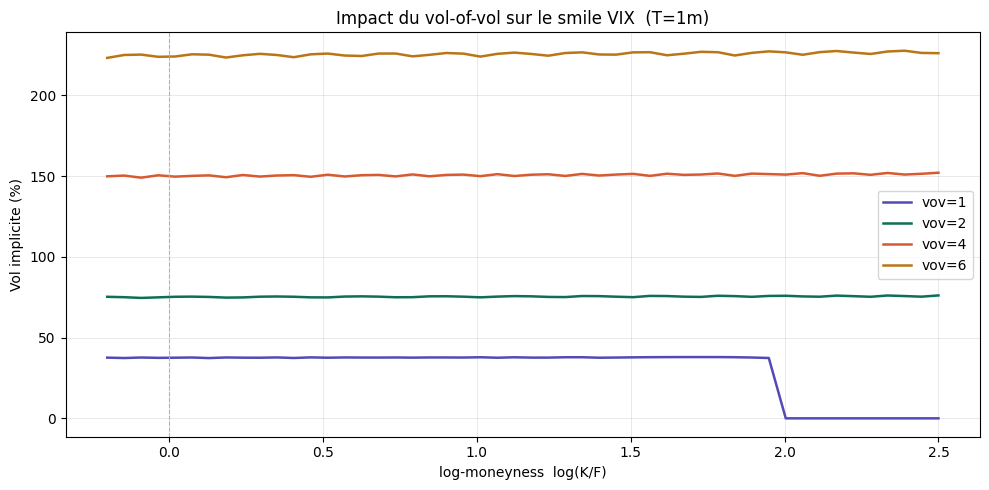

In [ ]:
# ── 1. Impact du vol-of-vol sur le future VIX ─────────────────────────────────
vov_grid = [1, 2, 4, 6]
T_ref    = 1/12

print("=== Impact du vol-of-vol sur le future VIX ===")
print(f"{'vov':>8} | " + " | ".join(f"{'T='+str(round(T*12))+'m':>10}" for T in maturities))
print("-" * 58)
for w in vov_grid:
    vals = [gaussian_quad(T, tau, w, theta, k_1, k_2, xi_0,
                          rho_x1x2, n_gh=50)
            for T in maturities]
    print(f"{w:>8.1f} | " + " | ".join(f"{v:>.4f}" for v in vals))

# ── 2. Smile VIX pour différents vol-of-vol ───────────────────────────────────
colors_vov = ['#534AB7', '#0F6E56', '#D85A30', '#BA7517', '#993556', '#185FA5']
T_smile    = 1/12

fig, ax = plt.subplots(figsize=(10, 5))
for idx, w in enumerate(vov_grid):
    F = gaussian_quad(T_smile, tau, w, theta, k_1, k_2, xi_0,
                      rho_x1x2, n_gh=50)
    prices = np.array([
        gaussian_quad(T_smile, tau, w, theta, k_1, k_2, xi_0,
                      rho_x1x2, n_gh=50,
                      h=lambda x, K=K: np.maximum(x - K, 0.0))
        for K in F * np.exp(lm_grid)
    ])
    ivols = black_iv(prices, F, T_smile, lm_grid)
    ax.plot(lm_grid, ivols * 100, color=colors_vov[idx],
            linewidth=1.8, label=f"vov={w}")

ax.axvline(0, color='#B4B2A9', linewidth=0.8, linestyle='--')
ax.set_xlabel("log-moneyness  log(K/F)")
ax.set_ylabel("Vol implicite (%)")
ax.set_title(f"Impact du vol-of-vol sur le smile VIX  (T={T_smile*12:.0f}m)")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()


=== One-factor Bergomi (θ=0) : future VIX par k₁ ===
      k1 |       T=1m |       T=2m |       T=3m |       T=4m
----------------------------------------------------------
       1 | 0.1373 | 0.1218 | 0.1101 | 0.1011
       5 | 0.1466 | 0.1420 | 0.1400 | 0.1391
      10 | 0.1524 | 0.1513 | 0.1511 | 0.1511
      30 | 0.1574 | 0.1574 | 0.1574 | 0.1574
      60 | 0.1580 | 0.1580 | 0.1580 | 0.1580
     100 | 0.1581 | 0.1581 | 0.1581 | 0.1581


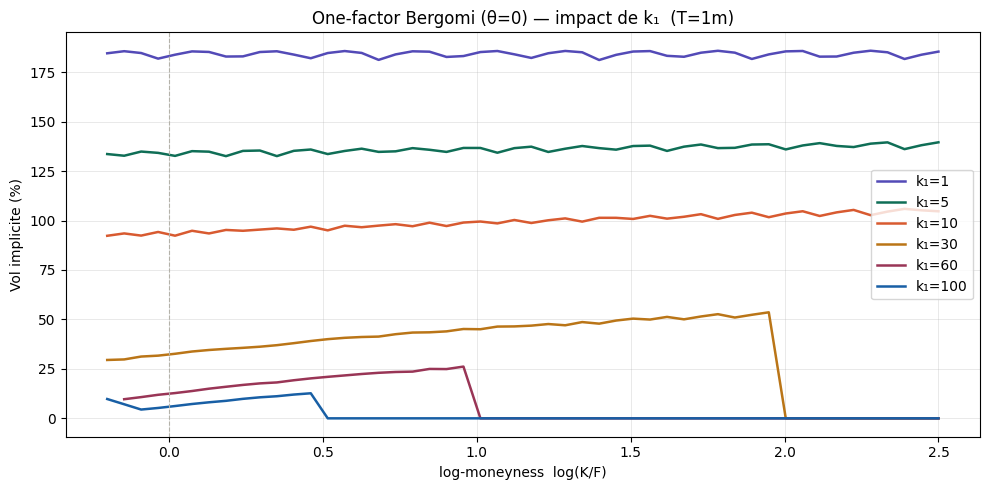

In [ ]:
# ── 3. Modèle one-factor Bergomi (θ=0) : impact de la mean reversion ──────────
k1_grid = [1, 5, 10, 30, 60, 100]
theta_1f = 0.0    # one-factor : θ=0, seul X¹ contribue

print("\n=== One-factor Bergomi (θ=0) : future VIX par k₁ ===")
print(f"{'k1':>8} | " + " | ".join(f"{'T='+str(round(T*12))+'m':>10}" for T in maturities))
print("-" * 58)
for k in k1_grid:
    vals = [gaussian_quad(T, tau, vov, theta_1f, k, k_2, xi_0,
                          rho_x1x2, n_gh=50)
            for T in maturities]
    print(f"{k:>8.0f} | " + " | ".join(f"{v:>.4f}" for v in vals))

# ── 4. Smile one-factor pour différents k₁ ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
for idx, k in enumerate(k1_grid):
    F = gaussian_quad(T_smile, tau, vov, theta_1f, k, k_2, xi_0,
                      rho_x1x2, n_gh=50)
    prices = np.array([
        gaussian_quad(T_smile, tau, vov, theta_1f, k, k_2, xi_0,
                      rho_x1x2, n_gh=50,
                      h=lambda x, K=K: np.maximum(x - K, 0.0))
        for K in F * np.exp(lm_grid)
    ])
    ivols = black_iv(prices, F, T_smile, lm_grid)
    ax.plot(lm_grid, ivols * 100, color=colors_vov[idx],
            linewidth=1.8, label=f"k₁={k}")

ax.axvline(0, color='#B4B2A9', linewidth=0.8, linestyle='--')
ax.set_xlabel("log-moneyness  log(K/F)")
ax.set_ylabel("Vol implicite (%)")
ax.set_title(f"One-factor Bergomi (θ=0) — impact de k₁  (T={T_smile*12:.0f}m)")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

**Comment (Q7):**

**Impact of $\omega$ (vol-of-vol):**
- **VIX futures** increase with ω. Since the VIX is a concave function of X and we use Jensen's inequality, larger vol-of-vol actually lowers $E[VIX]$ (Jensen's inequality). However, the *convexity adjustment* means that for large ω, the distribution of VIX is more right-skewed, and $E[VIX]$ may increase via the right tail. In our parametrization, higher $\omega$ increases the spread of the distribution of $VIX^2$.
- **VIX implied vols** increase strongly with ω. Larger $\omega$ means the distribution of VIX at maturity has fatter tails and stronger positive skew, directly inflating VIX option prices.

**Impact of $k_1$ in the one-factor model ($\theta=0$):**
- **Small $k_1$** (slow reversion): The vol factor $X_1$ at time T has high variance, making VIX highly variable and the VIX smile steep and wide.
- **Large $k_1$** (fast reversion): $X_1$ reverts quickly to 0, so at the VIX maturity T (which may be short, e.g. 1 month), the variance of $X_1$ is small. The VIX distribution is concentrated and the smile flattens. In the limit $k_1$ tends to $\infty$, the one-factor model converges to a constant vol model with no VIX smile.
This illustrates why a *two-factor* model is needed: one fast factor for short-term VIX dynamics and one slow factor for the long-term term structure of vol.

**References:**
\[1\] <a id="1"></a> Peter Jäckel, Anote on multivariate Gauss-Hermite quadrature